In [1]:
import pandas as pd
import numpy as np
import re
from IPython.display import display
pd.options.display.max_colwidth=100
pd.options.display.float_format="{:.2f}".format
pd.set_option("display.max_columns", None)
import warnings
warnings.simplefilter('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as pl
%pip install chart_studio
sns.set_theme(style='darkgrid')
import tensorflow as tf
import keras_tuner as kt
np.set_printoptions(precision=3, suppress=True)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, auc,roc_curve,classification_report,confusion_matrix,mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.model_selection import train_test_split

from lightgbm import LGBMRegressor
from itertools import product
import random
import math


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load the datasets
# intakes_df = pd.read_csv('/content/drive/MyDrive/Austin_Animal_Center_Intakes.csv')
# outcomes_df = pd.read_csv('/content/drive/MyDrive/Austin_Animal_Center_Outcomes.csv')


# Load the datasets
intakes_df = pd.read_csv('Austin_Animal_Center_Intakes.csv')
outcomes_df = pd.read_csv('Austin_Animal_Center_Outcomes.csv')


print("Intakes DataFrame:")
display(intakes_df.head())

print("\nOutcomes DataFrame:")
display(outcomes_df.head())

print("Intakes DataFrame Info:")
intakes_df.info()

print("\nOutcomes DataFrame Info:")
outcomes_df.info()

Intakes DataFrame:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
0,A521520,Nina,10/01/2013 07:51:00 AM,October 2013,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
3,A664237,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
4,A664233,Stevie,10/01/2013 08:53:00 AM,October 2013,7405 Springtime in Austin (TX),Stray,Injured,Dog,Intact Female,3 years,Pit Bull Mix,Blue/White



Outcomes DataFrame:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


Intakes DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173812 entries, 0 to 173811
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         173812 non-null  object
 1   Name              123821 non-null  object
 2   DateTime          173812 non-null  object
 3   MonthYear         173812 non-null  object
 4   Found Location    173812 non-null  object
 5   Intake Type       173812 non-null  object
 6   Intake Condition  173812 non-null  object
 7   Animal Type       173812 non-null  object
 8   Sex upon Intake   173811 non-null  object
 9   Age upon Intake   173812 non-null  object
 10  Breed             173812 non-null  object
 11  Color             173812 non-null  object
dtypes: object(12)
memory usage: 15.9+ MB

Outcomes DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173775 entries, 0 to 173774
Data columns (total 12 columns):
 #   Column            Non-N

In [3]:
print("Unique values for columns in intakes_df:")
for col in intakes_df.columns:
    print(f"Unique values for column: {col}")
    unique_values = intakes_df[col].unique()
    if len(unique_values) > 50:
        print(unique_values[:50])
        print(f"... and {len(unique_values) - 50} more unique values.")
    else:
        print(unique_values)
    print("-" * 50)

print("\nUnique values for columns in outcomes_df:")
for col in outcomes_df.columns:
    print(f"Unique values for column: {col}")
    unique_values = outcomes_df[col].unique()
    if len(unique_values) > 50:
        print(unique_values[:50])
        print(f"... and {len(unique_values) - 50} more unique values.")
    else:
        print(unique_values)
    print("-" * 50)

Unique values for columns in intakes_df:
Unique values for column: Animal ID
['A521520' 'A664235' 'A664236' 'A664237' 'A664233' 'A664238' 'A664234'
 'A664256' 'A664257' 'A664266' 'A664258' 'A648744' 'A664260' 'A664261'
 'A651630' 'A664259' 'A664269' 'A664262' 'A664263' 'A664264' 'A664265'
 'A664267' 'A664268' 'A664271' 'A664272' 'A664273' 'A639030' 'A664253'
 'A664274' 'A658012' 'A636021' 'A664275' 'A664277' 'A664280' 'A660220'
 'A634503' 'A664281' 'A664282' 'A664283' 'A664284' 'A664285' 'A664286'
 'A664287' 'A664288' 'A659642' 'A664289' 'A664292' 'A664293' 'A664294'
 'A664295']
... and 156237 more unique values.
--------------------------------------------------
Unique values for column: Name
['Nina' nan 'Stevie' '*Donnie' 'Pippin' 'Sylvio' 'Claire' 'Heather'
 '*Petunia' '*Bismark' '*Mason' '*Dixon' '*Asti' '*Kochka' '*Grace'
 'Buffy' 'Cate' 'Moose' 'Estrella' 'Lucio' 'Sera' 'Mcdermot' '*Pogo'
 'Coco' 'Jade' 'Otter' 'Juliet' 'Sugar' 'Daisy' '*Trevor' '*Romeo'
 '*Juliet' '*Paris' '*Mer

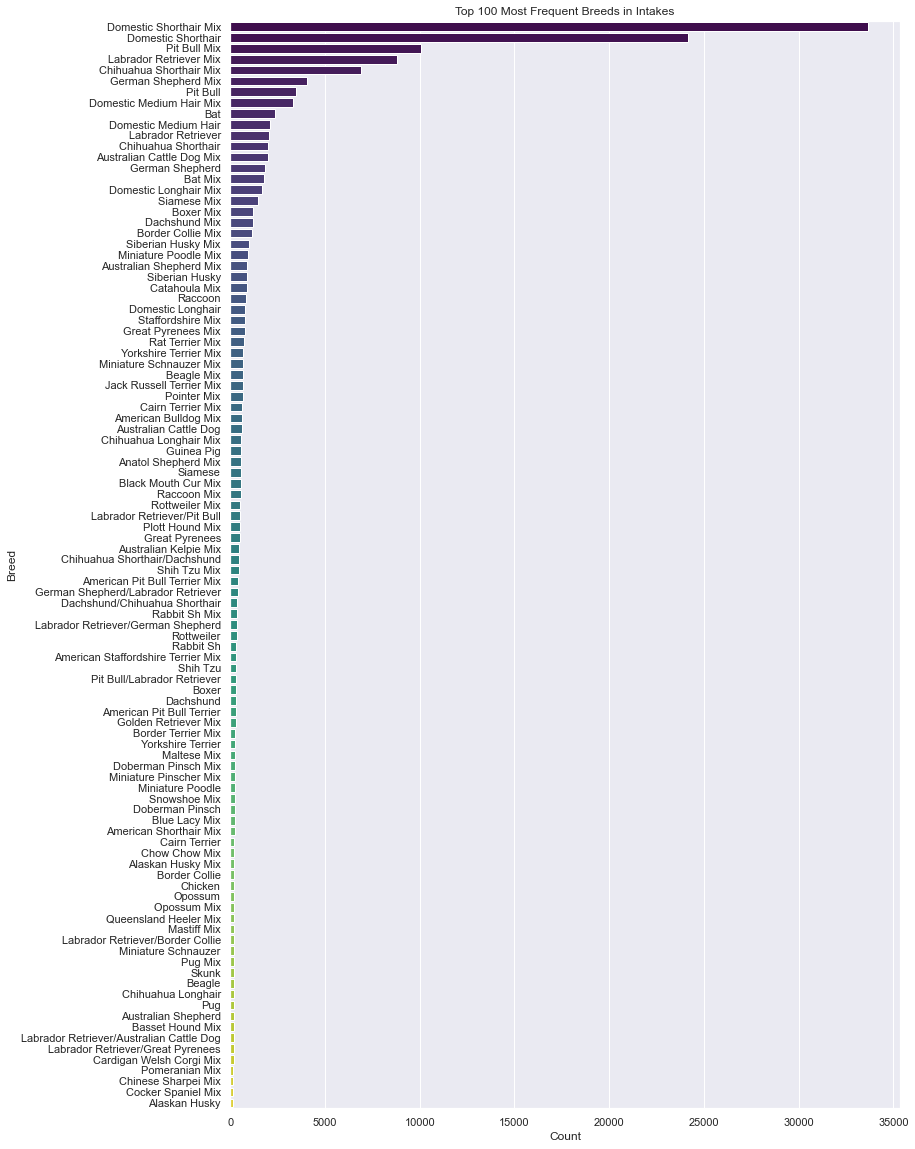

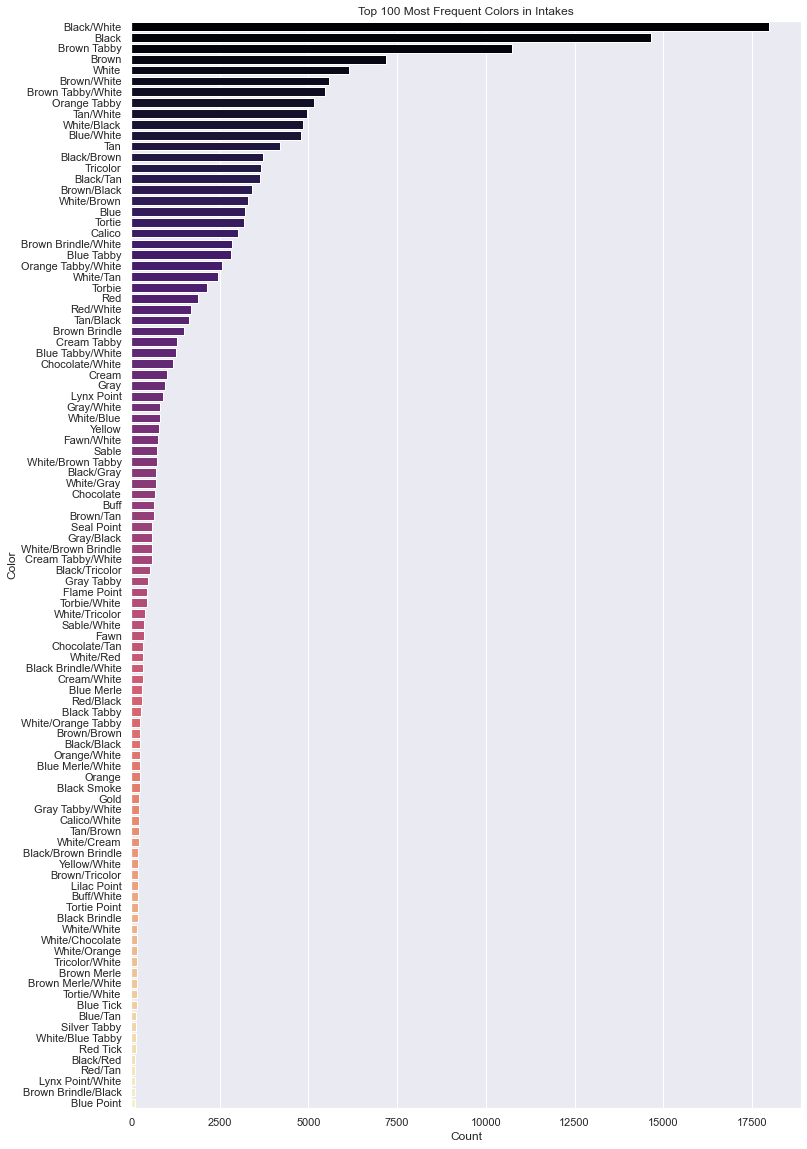

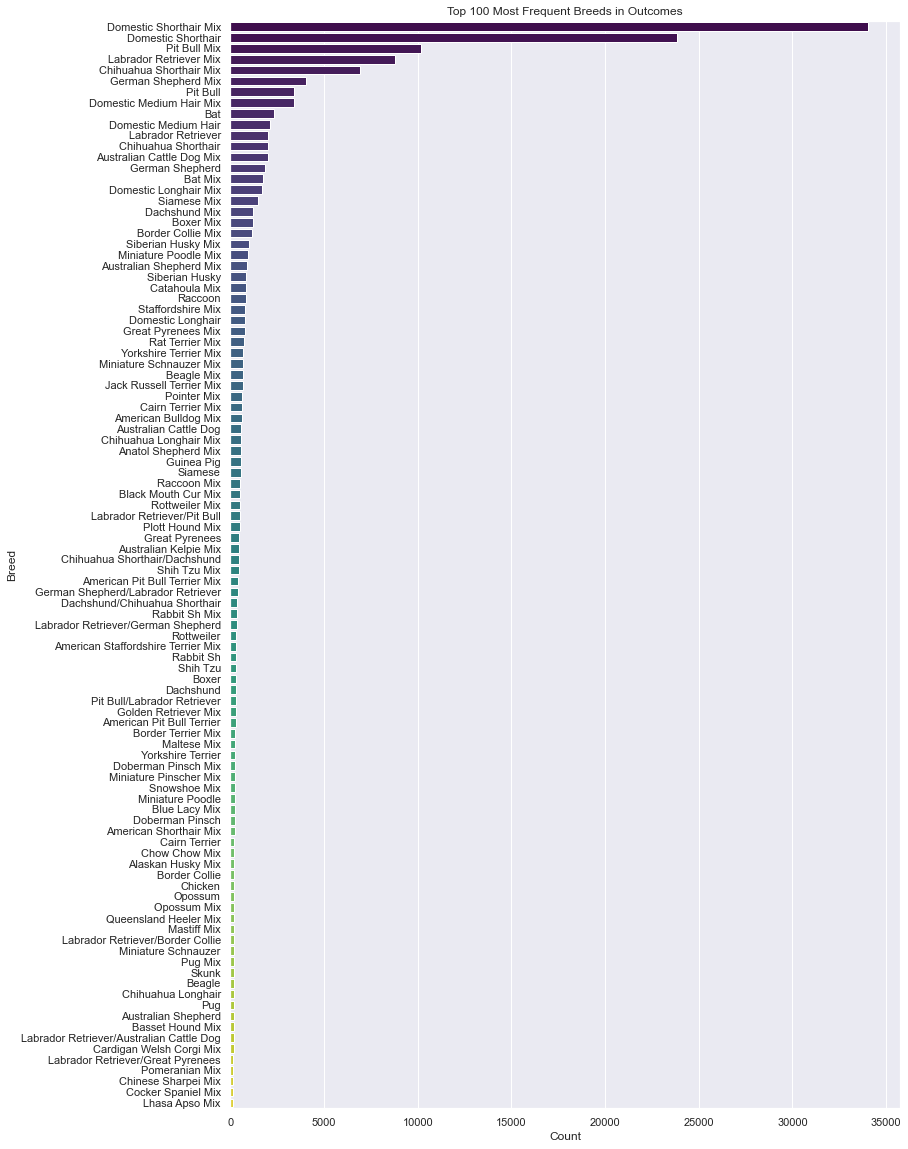

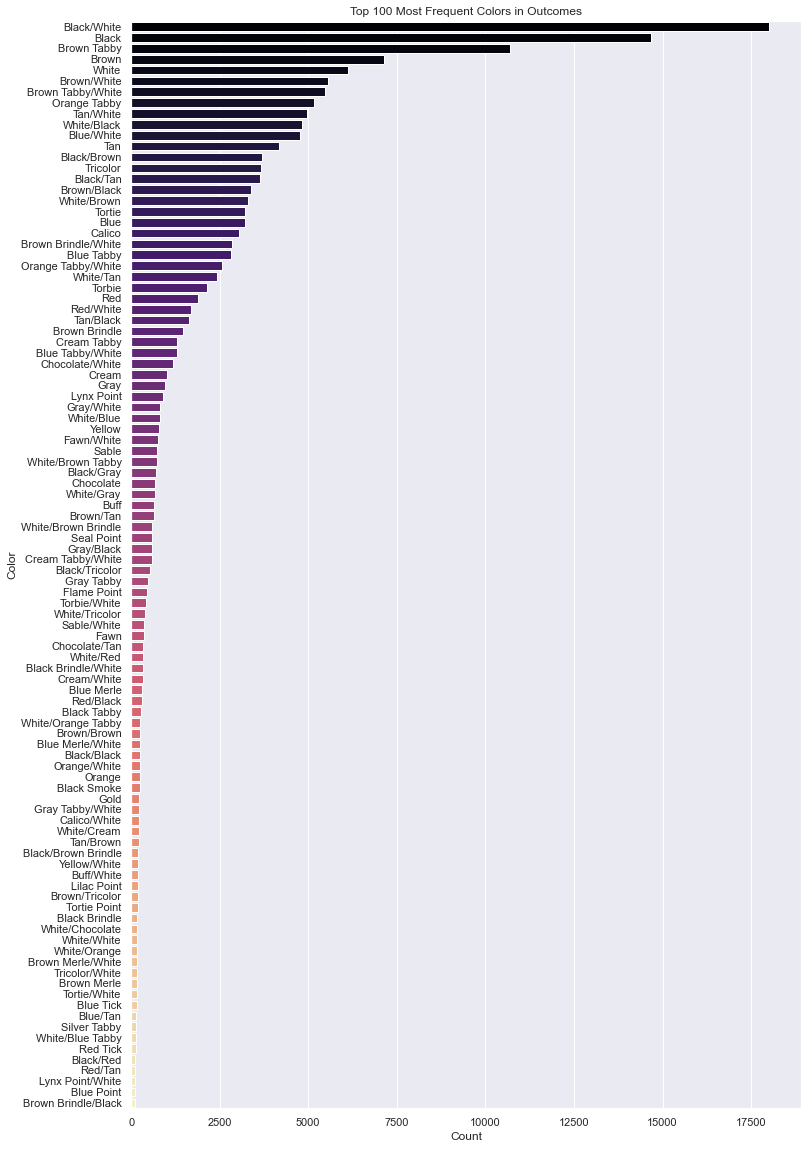

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 100 most frequent breeds in intakes_df and sort them
top_intake_breeds = intakes_df['Breed'].value_counts().nlargest(100).index
# Plot the count of top breeds in intakes_df with flipped axes
plt.figure(figsize=(12, 20)) # Adjust figure size for better readability with more bars
sns.countplot(data=intakes_df, y='Breed', order=top_intake_breeds, palette='viridis')
plt.title('Top 100 Most Frequent Breeds in Intakes')
plt.xlabel('Count')
plt.ylabel('Breed')
plt.show()

# Get the top 100 most frequent colors in intakes_df and sort them
top_intake_colors = intakes_df['Color'].value_counts().nlargest(100).index
# Plot the count of top colors in intakes_df with flipped axes
plt.figure(figsize=(12, 20)) # Adjust figure size
sns.countplot(data=intakes_df, y='Color', order=top_intake_colors, palette='magma')
plt.title('Top 100 Most Frequent Colors in Intakes')
plt.xlabel('Count')
plt.ylabel('Color')
plt.show()

# Get the top 100 most frequent breeds in outcomes_df and sort them
top_outcome_breeds = outcomes_df['Breed'].value_counts().nlargest(100).index
# Plot the count of top breeds in outcomes_df with flipped axes
plt.figure(figsize=(12, 20)) # Adjust figure size
sns.countplot(data=outcomes_df, y='Breed', order=top_outcome_breeds, palette='viridis')
plt.title('Top 100 Most Frequent Breeds in Outcomes')
plt.xlabel('Count')
plt.ylabel('Breed')
plt.show()

# Get the top 100 most frequent colors in outcomes_df and sort them
top_outcome_colors = outcomes_df['Color'].value_counts().nlargest(100).index
# Plot the count of top colors in outcomes_df with flipped axes
plt.figure(figsize=(12, 20)) # Adjust figure size
sns.countplot(data=outcomes_df, y='Color', order=top_outcome_colors, palette='magma')
plt.title('Top 100 Most Frequent Colors in Outcomes')
plt.xlabel('Count')
plt.ylabel('Color')
plt.show()

# Handling Duplicates

In [5]:
# Number of duplicate rows in intakes_df
num_duplicates_intakes = intakes_df.duplicated().sum()
print(f"Number of duplicate rows in intakes_df: {num_duplicates_intakes}")

# Number of duplicate rows in outcomes_df
num_duplicates_outcomes = outcomes_df.duplicated().sum()
print(f"Number of duplicate rows in outcomes_df: {num_duplicates_outcomes}")

Number of duplicate rows in intakes_df: 36
Number of duplicate rows in outcomes_df: 26


In [6]:
# Drop exact duplicate rows from intakes_df
intakes_df = intakes_df.drop_duplicates()
print(f"Number of rows in intakes_df after dropping duplicates: {len(intakes_df)}")

# Drop exact duplicate rows from outcomes_df
outcomes_df = outcomes_df.drop_duplicates()
print(f"Number of rows in outcomes_df after dropping duplicates: {len(outcomes_df)}")

Number of rows in intakes_df after dropping duplicates: 173776
Number of rows in outcomes_df after dropping duplicates: 173749


In [7]:
# Count the occurrences of each 'Animal ID' in dfs
intake_id_counts = intakes_df['Animal ID'].value_counts()
outcome_id_counts = outcomes_df['Animal ID'].value_counts()

# Filter for IDs that appear more than once
duplicate_intake_ids = intake_id_counts[intake_id_counts > 1]
duplicate_outcome_ids = outcome_id_counts[outcome_id_counts > 1]

print("Number of duplicate 'Animal ID's in intakes_df:")
print(len(duplicate_intake_ids))

print("\n'Animal ID's with multiple intakes:")
print(duplicate_intake_ids.head())

print("Number of duplicate 'Animal ID's in outcomes_df:")
print(len(duplicate_outcome_ids))

print("\n'Animal ID's with multiple outcomes:")
print(duplicate_outcome_ids.head())

Number of duplicate 'Animal ID's in intakes_df:
13461

'Animal ID's with multiple intakes:
Animal ID
A721033    33
A718223    14
A718877    12
A705625    12
A706536    11
Name: count, dtype: int64
Number of duplicate 'Animal ID's in outcomes_df:
13486

'Animal ID's with multiple outcomes:
Animal ID
A721033    33
A718223    14
A718877    12
A706536    11
A705625    11
Name: count, dtype: int64


Shows inconsistency in Intake and Outake Data:

In [8]:
# Count entries for each Animal ID in intakes_df
intake_counts = intakes_df['Animal ID'].value_counts().reset_index()
intake_counts.columns = ['Animal ID', 'Intake_Count']

# Count entries for each Animal ID in outcomes_df
outcome_counts = outcomes_df['Animal ID'].value_counts().reset_index()
outcome_counts.columns = ['Animal ID', 'Outcome_Count']

# Merge the counts
merged_counts = pd.merge(intake_counts, outcome_counts, on='Animal ID', how='outer').fillna(0)

# Convert counts to integer type
merged_counts['Intake_Count'] = merged_counts['Intake_Count'].astype(int)
merged_counts['Outcome_Count'] = merged_counts['Outcome_Count'].astype(int)


# Filter for Animal IDs where the counts do not match
mismatched_counts = merged_counts[merged_counts['Intake_Count'] != merged_counts['Outcome_Count']]

print("Animal IDs with mismatched intake and outcome entry counts:")
display(mismatched_counts)

print(f"\nNumber of Animal IDs with mismatched counts: {len(mismatched_counts)}")

Animal IDs with mismatched intake and outcome entry counts:


,Animal ID,Intake_Count,Outcome_Count
3,A705625,12,11
451,A867245,4,3
530,A913619,4,3
614,A661049,4,5
621,A668183,4,5
...,...,...,...
157096,A504391,0,1
157097,A657652,0,1
157098,A647113,0,1
157099,A655298,0,1



Number of Animal IDs with mismatched counts: 1907


Example of animal that has multiple Intakes and Outakes.

In [9]:
# Filter intakes_df for Animal ID 'A721033'
intakes_A721033 = intakes_df[intakes_df['Animal ID'] == 'A721033']

print("Entries for Animal ID A721033 in intakes_df:")
display(intakes_A721033)

# Filter outcomes_df for Animal ID 'A721033'
outcomes_A721033 = outcomes_df[outcomes_df['Animal ID'] == 'A721033']

print("\nEntries for Animal ID A721033 in outcomes_df:")
display(outcomes_A721033)

Entries for Animal ID A721033 in intakes_df:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
43498,A721033,Lil Bit,02/20/2016 10:44:00 AM,February 2016,2508 E Riverside Dr in Austin (TX),Stray,Normal,Dog,Neutered Male,9 months,Rat Terrier Mix,Tricolor/Brown Brindle
51001,A721033,Lil Bit,07/10/2016 11:53:00 AM,July 2016,6317 E Ben White Blvd in Austin (TX),Stray,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
53835,A721033,Lil Bit,09/03/2016 02:30:00 PM,September 2016,6010 E Riverside in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
56121,A721033,Lil Bit,10/20/2016 10:47:00 PM,October 2016,6200 E. Ben White Blvd in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
58575,A721033,Lil Bit,12/15/2016 10:07:00 AM,December 2016,S Pleasant Valley Rd And E Riverside Dr in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
59568,A721033,Lil Bit,01/09/2017 02:26:00 PM,January 2017,6210 E Ben White Blvd in Austin (TX),Stray,Injured,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
60211,A721033,Lil Bit,01/26/2017 06:55:00 AM,January 2017,901 W Ben White Blvd in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
60407,A721033,Lil Bit,01/30/2017 11:05:00 PM,January 2017,6210 E Ben White in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
60647,A721033,Lil Bit,02/06/2017 10:13:00 AM,February 2017,6210 E Ben White in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
62261,A721033,Lil Bit,03/15/2017 09:24:00 AM,March 2017,E Ben White Blvd & Montopolis Dr in Austin (TX),Public Assist,Normal,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle



Entries for Animal ID A721033 in outcomes_df:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
45568,A721033,2015-05-20,Lil Bit,2016-02-20T16:18:00,02-2016,Return to Owner,NaN,Dog,Neutered Male,9 months,Rat Terrier Mix,Tricolor/Brown Brindle
52371,A721033,2015-05-20,Lil Bit,2016-07-11T17:44:00,07-2016,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
55434,A721033,2015-05-20,Lil Bit,2016-09-12T13:40:00,09-2016,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
57306,A721033,2015-05-20,Lil Bit,2016-10-21T18:55:00,10-2016,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
59742,A721033,2015-05-20,Lil Bit,2016-12-16T11:32:00,12-2016,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
60834,A721033,2015-05-20,Lil Bit,2017-01-10T16:20:00,01-2017,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
61554,A721033,2015-05-20,Lil Bit,2017-01-28T15:22:00,01-2017,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
61789,A721033,2015-05-20,Lil Bit,2017-02-02T11:19:00,02-2017,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
62014,A721033,2015-05-20,Lil Bit,2017-02-07T17:26:00,02-2017,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle
63623,A721033,2015-05-20,Lil Bit,2017-03-16T12:50:00,03-2017,Return to Owner,NaN,Dog,Neutered Male,1 year,Rat Terrier Mix,Tricolor/Brown Brindle


Example of animal that shows up in Outcomes but not Intakes.

In [10]:
# Filter intakes_df for Animal ID 'A721033'
intakes_A275975 = intakes_df[intakes_df['Animal ID'] == 'A275975']

print("Entries for Animal ID A275975 in intakes_df:")
display(intakes_A275975)

# Filter outcomes_df for Animal ID 'A275975'
outcomes_A275975 = outcomes_df[outcomes_df['Animal ID'] == 'A275975']

print("\nEntries for Animal ID A275975 in outcomes_df:")
display(outcomes_A275975)

Entries for Animal ID A275975 in intakes_df:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color



Entries for Animal ID A275975 in outcomes_df:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
2951,A275975,2002-03-12,Squeakers,2013-10-12T11:27:00,10-2013,Adoption,NaN,Cat,Spayed Female,11 years,Domestic Shorthair Mix,Black


Drop the entries from the outcomes data that did not have a corresponding intake record:

In [11]:
# Get the list of Animal IDs present in intakes_df
intake_animal_ids = intakes_df['Animal ID'].unique()

# Filter outcomes_df to keep only rows where 'Animal ID' is in intake_animal_ids
outcomes_df_filtered = outcomes_df[outcomes_df['Animal ID'].isin(intake_animal_ids)].copy()

print(f"Number of rows in outcomes_df before filtering: {len(outcomes_df)}")
print(f"Number of rows in outcomes_df after filtering: {len(outcomes_df_filtered)}")

print("\nFirst 5 rows of filtered outcomes_df:")
display(outcomes_df_filtered.head())

Number of rows in outcomes_df before filtering: 173749
Number of rows in outcomes_df after filtering: 172935

First 5 rows of filtered outcomes_df:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


Example of animal that has more outcomes than intakes.

In [12]:
# Filter intakes_df for Animal ID 'A483240'
intakes_A483240 = intakes_df[intakes_df['Animal ID'] == 'A483240']

print("Entries for Animal ID A483240 in intakes_df:")
display(intakes_A483240)

# Filter outcomes_df for Animal ID 'A483240'
outcomes_A483240 = outcomes_df[outcomes_df['Animal ID'] == 'A483240']

print("\nEntries for Animal ID A483240 in outcomes_df:")
display(outcomes_A483240)

Entries for Animal ID A483240 in intakes_df:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
2892,A483240,Frassina,11/30/2013 02:30:00 PM,November 2013,Outside Jurisdiction,Owner Surrender,Normal,Cat,Spayed Female,6 years,Domestic Longhair/Persian,Blue Cream



Entries for Animal ID A483240 in outcomes_df:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
4745,A483240,2007-06-17,Frassina,2013-11-16T15:58:00,11-2013,Adoption,NaN,Cat,Spayed Female,6 years,Domestic Longhair/Persian,Blue Cream
5511,A483240,2007-06-17,Frassina,2013-12-04T13:33:00,12-2013,Adoption,Foster,Cat,Spayed Female,6 years,Domestic Longhair/Persian,Blue Cream


# Reconciliation
Create episodes for each animal by pairing consecutive intake and outcome records from `intakes_df` and `outcomes_df_filtered`, handling potential mismatches, and store the results in a new structure.

Ensure the 'DateTime' columns in both `intakes_df` and `outcomes_df_filtered` are in datetime format and sort the dataframes by 'Animal ID' and 'DateTime'.


In [13]:
intakes_df['DateTime'] = pd.to_datetime(intakes_df['DateTime'])
outcomes_df_filtered['DateTime'] = pd.to_datetime(outcomes_df_filtered['DateTime'], format='mixed', utc=True).dt.tz_convert(None)

intakes_df = intakes_df.sort_values(by=['Animal ID', 'DateTime'])
outcomes_df_filtered = outcomes_df_filtered.sort_values(by=['Animal ID', 'DateTime'])

print("Intakes DataFrame after sorting:")
display(intakes_df.head())
print("\nOutcomes DataFrame after sorting:")
display(outcomes_df_filtered.head())

Intakes DataFrame after sorting:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
6926,A006100,Scamp,2014-03-07 14:26:00,March 2014,8700 Research in Austin (TX),Public Assist,Normal,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White
22374,A006100,Scamp,2014-12-19 10:21:00,December 2014,8700 Research Blvd in Austin (TX),Public Assist,Normal,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White
75925,A006100,Scamp,2017-12-07 14:07:00,December 2017,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
8236,A047759,Oreo,2014-04-02 15:55:00,April 2014,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,10 years,Dachshund,Tricolor
2309,A134067,Bandit,2013-11-16 09:02:00,November 2013,12034 Research Blvd in Austin (TX),Public Assist,Injured,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White



Outcomes DataFrame after sorting:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
9637,A006100,2007-07-09,Scamp,2014-03-08 17:10:00,03-2014,Return to Owner,NaN,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White
25064,A006100,2007-07-09,Scamp,2014-12-20 16:35:00,12-2014,Return to Owner,NaN,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White
1891,A006100,2007-07-09,Scamp,2017-12-07 05:00:00,12-2017,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
11094,A047759,2004-04-02,Oreo,2014-04-07 15:12:00,04-2014,Transfer,Partner,Dog,Neutered Male,10 years,Dachshund,Tricolor
4709,A134067,1997-10-16,Bandit,2013-11-16 11:54:00,11-2013,Return to Owner,NaN,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White


## Visit creation

Iterate through each animal's records, pairing consecutive intake and outcome records as visits. Handle cases with mismatched numbers of intakes and outcomes.


In [14]:
# Group the dataframes by 'Animal ID' and initialize an empty list to store visits
grouped_intakes = intakes_df.groupby('Animal ID')
grouped_outcomes = outcomes_df_filtered.groupby('Animal ID')

visits = []
unmatched_intakes = []
unmatched_outcomes = []

In [15]:
# Iterate through each animal ID and pair consecutive intake and outcome records to create visits, handling unmatched records
for animal_id, intake_group in grouped_intakes:
    intake_records = intake_group.to_dict('records')
    outcome_records = grouped_outcomes.get_group(animal_id).to_dict('records') if animal_id in grouped_outcomes.groups else []

    used_outcomes_indices = set()

    for intake in intake_records:
        matched_outcome = None
        for i, outcome in enumerate(outcome_records):
            if i not in used_outcomes_indices and outcome['DateTime'] >= intake['DateTime']:
                matched_outcome = outcome
                used_outcomes_indices.add(i)
                break

        if matched_outcome:
            visit = {
                'Animal ID': animal_id,
                'Intake': intake,
                'Outcome': matched_outcome
            }
            visits.append(visit)
        else:
            unmatched_intakes.append(intake)

    for i, outcome in enumerate(outcome_records):
        if i not in used_outcomes_indices:
            unmatched_outcomes.append(outcome)

print(f"Number of visits created: {len(visits)}")
print(f"Number of unmatched intakes: {len(unmatched_intakes)}")
print(f"Number of unmatched outcomes: {len(unmatched_outcomes)}")

Number of visits created: 172171
Number of unmatched intakes: 1605
Number of unmatched outcomes: 764


### Store visits

Store the created visits in a new structure


In [16]:
# Create a list of dictionaries from the episodes and calculate the duration of stay, then convert it to a dataframe

visit_list = []

for visit in visits:
    intake_details = visit['Intake']
    outcome_details = visit['Outcome']

    # Extract relevant information from intake and outcome records
    visit_data = {
        'Animal ID': visit['Animal ID'],
        'Intake_DateTime': intake_details['DateTime'],
        'Intake_Type': intake_details['Intake Type'],
        'Intake_Condition': intake_details['Intake Condition'],
        'Intake_Animal_Type': intake_details['Animal Type'],
        'Intake_Sex': intake_details['Sex upon Intake'],
        'Intake_Age': intake_details['Age upon Intake'],
        'Intake_Breed': intake_details['Breed'],
        'Intake_Color': intake_details['Color'],
        'Outcome_DateTime': outcome_details['DateTime'] if outcome_details else None,
        'Outcome_Type': outcome_details['Outcome Type'] if outcome_details else None,
        'Outcome_Subtype': outcome_details['Outcome Subtype'] if outcome_details else None,
        'Outcome_Animal_Type': outcome_details['Animal Type'] if outcome_details else None,
        'Outcome_Sex': outcome_details['Sex upon Outcome'] if outcome_details else None,
        'Outcome_Age': outcome_details['Age upon Outcome'] if outcome_details else None,
        'Outcome_Breed': outcome_details['Breed'] if outcome_details else None,
        'Outcome_Color': outcome_details['Color'] if outcome_details else None,
    }

    # Calculate duration of stay
    if visit_data['Outcome_DateTime'] is not None:
        visit_data['duration_of_stay'] = (visit_data['Outcome_DateTime'] - visit_data['Intake_DateTime']).total_seconds() / (24 * 3600) # Duration in days
    else:
        visit_data['duration_of_stay'] = None

    visit_list.append(visit_data)

# Convert the list of dictionaries to a DataFrame
visits_df = pd.DataFrame(visit_list)

# Display the first few rows and information of the new DataFrame
print("Visits DataFrame:")
display(visits_df.head())
print("\nVisits DataFrame Info:")
visits_df.info()

Visits DataFrame:


,Animal ID,Intake_DateTime,Intake_Type,Intake_Condition,Intake_Animal_Type,Intake_Sex,Intake_Age,Intake_Breed,Intake_Color,Outcome_DateTime,Outcome_Type,Outcome_Subtype,Outcome_Animal_Type,Outcome_Sex,Outcome_Age,Outcome_Breed,Outcome_Color,duration_of_stay
0,A006100,2014-03-07 14:26:00,Public Assist,Normal,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White,2014-03-08 17:10:00,Return to Owner,NaN,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White,1.11
1,A006100,2014-12-19 10:21:00,Public Assist,Normal,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White,2014-12-20 16:35:00,Return to Owner,NaN,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White,1.26
2,A047759,2014-04-02 15:55:00,Owner Surrender,Normal,Dog,Neutered Male,10 years,Dachshund,Tricolor,2014-04-07 15:12:00,Transfer,Partner,Dog,Neutered Male,10 years,Dachshund,Tricolor,4.97
3,A134067,2013-11-16 09:02:00,Public Assist,Injured,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White,2013-11-16 11:54:00,Return to Owner,NaN,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White,0.12
4,A141142,2013-11-16 14:46:00,Stray,Aged,Dog,Spayed Female,15 years,Labrador Retriever/Pit Bull,Black/White,2013-11-17 11:40:00,Return to Owner,NaN,Dog,Spayed Female,15 years,Labrador Retriever/Pit Bull,Black/White,0.87



Visits DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172171 entries, 0 to 172170
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Animal ID            172171 non-null  object        
 1   Intake_DateTime      172171 non-null  datetime64[ns]
 2   Intake_Type          172171 non-null  object        
 3   Intake_Condition     172171 non-null  object        
 4   Intake_Animal_Type   172171 non-null  object        
 5   Intake_Sex           172170 non-null  object        
 6   Intake_Age           172171 non-null  object        
 7   Intake_Breed         172171 non-null  object        
 8   Intake_Color         172171 non-null  object        
 9   Outcome_DateTime     172171 non-null  datetime64[ns]
 10  Outcome_Type         172129 non-null  object        
 11  Outcome_Subtype      78613 non-null   object        
 12  Outcome_Animal_Type  172171 non-null  object    

Example of animal that was supposed to have 3 episodes but only has 2 because the time for the last outcome was likely entered wrong.

In [17]:
# Filter the sorted intakes_df for Animal ID 'A006100'
intakes_A006100_sorted = intakes_df[intakes_df['Animal ID'] == 'A006100']

print("Entries for Animal ID A006100 in sorted intakes_df:")
display(intakes_A006100_sorted)

# Filter the sorted outcomes_df_filtered for Animal ID 'A006100'
outcomes_A006100_sorted = outcomes_df_filtered[outcomes_df_filtered['Animal ID'] == 'A006100']

print("\nEntries for Animal ID A006100 in sorted outcomes_df_filtered:")
display(outcomes_A006100_sorted)

Entries for Animal ID A006100 in sorted intakes_df:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
6926,A006100,Scamp,2014-03-07 14:26:00,March 2014,8700 Research in Austin (TX),Public Assist,Normal,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White
22374,A006100,Scamp,2014-12-19 10:21:00,December 2014,8700 Research Blvd in Austin (TX),Public Assist,Normal,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White
75925,A006100,Scamp,2017-12-07 14:07:00,December 2017,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White



Entries for Animal ID A006100 in sorted outcomes_df_filtered:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
9637,A006100,2007-07-09,Scamp,2014-03-08 17:10:00,03-2014,Return to Owner,NaN,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White
25064,A006100,2007-07-09,Scamp,2014-12-20 16:35:00,12-2014,Return to Owner,NaN,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White
1891,A006100,2007-07-09,Scamp,2017-12-07 05:00:00,12-2017,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White


### Identify remaining mismatches



In [18]:
# Create DataFrames from unmatched lists
unmatched_intakes_df = pd.DataFrame(unmatched_intakes)
unmatched_outcomes_df = pd.DataFrame(unmatched_outcomes)

# Display the number of records in each DataFrame
print(f"Number of unmatched intake records: {len(unmatched_intakes_df)}")
print(f"Number of unmatched outcome records: {len(unmatched_outcomes_df)}")

# Display the first 5 rows of each DataFrame
print("\nFirst 5 rows of unmatched intakes:")
display(unmatched_intakes_df.head())

print("\nFirst 5 rows of unmatched outcomes:")
display(unmatched_outcomes_df.head())

Number of unmatched intake records: 1605
Number of unmatched outcome records: 764

First 5 rows of unmatched intakes:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
0,A006100,Scamp,2017-12-07 14:07:00,December 2017,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
1,A531969,Black,2015-11-13 12:18:00,November 2015,Outside Jurisdiction,Owner Surrender,Normal,Dog,Neutered Male,7 years,Pit Bull Mix,Black/White
2,A533243,Choco,2017-02-24 11:52:00,February 2017,Riverside Dr And Montopolis Dr in Austin (TX),Stray,Normal,Dog,Neutered Male,8 years,Labrador Retriever/Pit Bull,Chocolate
3,A554047,Mega,2016-07-05 18:48:00,July 2016,5205 Holmont Dr in Austin (TX),Stray,Normal,Dog,Neutered Male,6 years,Pit Bull Mix,Brown/White
4,A587232,Rosie,2022-02-01 08:24:00,February 2022,Springdale Road And East 7Th Street in Austin (TX),Stray,Sick,Dog,Spayed Female,12 years,Chihuahua Shorthair Mix,Black/White



First 5 rows of unmatched outcomes:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A006100,2007-07-09,Scamp,2017-12-07 05:00:00,12-2017,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
1,A483240,2007-06-17,Frassina,2013-11-16 15:58:00,11-2013,Adoption,NaN,Cat,Spayed Female,6 years,Domestic Longhair/Persian,Blue Cream
2,A531739,2008-02-29,Bentley,2013-11-30 13:31:00,11-2013,Adoption,NaN,Dog,Neutered Male,5 years,Pointer Mix,White/Tan
3,A531969,2008-03-06,Black,2015-11-13 05:00:00,11-2015,Return to Owner,NaN,Dog,Neutered Male,7 years,Pit Bull Mix,Black/White
4,A533243,2008-07-15,Choco,2016-12-20 05:00:00,12-2016,Return to Owner,NaN,Dog,Neutered Male,8 years,Labrador Retriever/Pit Bull,Chocolate


In [19]:
# Find Animal IDs that exist in both unmatched_intakes_df and unmatched_outcomes_df
animal_ids_in_both_unmatched = pd.merge(unmatched_intakes_df['Animal ID'], unmatched_outcomes_df['Animal ID'], on='Animal ID', how='inner')['Animal ID'].unique()

print("Animal IDs that appear in both unmatched intakes and unmatched outcomes:")
print(animal_ids_in_both_unmatched)
print(f"\nNumber of Animal IDs in both unmatched dataframes: {len(animal_ids_in_both_unmatched)}")

Animal IDs that appear in both unmatched intakes and unmatched outcomes:
['A006100' 'A531969' 'A533243' 'A554047' 'A587232' 'A621011' 'A624094'
 'A647489' 'A657016' 'A659667' 'A665649' 'A672396' 'A672696' 'A673335'
 'A674638' 'A675125' 'A675480' 'A676345' 'A678461' 'A678823' 'A678824'
 'A679066' 'A679180' 'A679181' 'A679182' 'A679215' 'A679217' 'A679222'
 'A679230' 'A679305' 'A679357' 'A679361' 'A679408' 'A679940' 'A679980'
 'A680032' 'A680057' 'A680058' 'A680106' 'A680138' 'A680141' 'A680144'
 'A680319' 'A680504' 'A680744' 'A681049' 'A681851' 'A681854' 'A681856'
 'A681857' 'A681858' 'A681860' 'A681862' 'A681863' 'A681864' 'A683591'
 'A683693' 'A684858' 'A697081' 'A699447' 'A699599' 'A699601' 'A699767'
 'A699768' 'A699769' 'A699770' 'A699771' 'A699779' 'A699780' 'A699781'
 'A699782' 'A699783' 'A699790' 'A699791' 'A699792' 'A700792' 'A701542'
 'A702081' 'A702777' 'A702786' 'A703445' 'A705624' 'A705626' 'A705627'
 'A705628' 'A705629' 'A705630' 'A705631' 'A705632' 'A705633' 'A705636'
 'A7

In [20]:
# Take a sample of Animal IDs that appear in both unmatched lists
sample_animal_ids = np.random.choice(animal_ids_in_both_unmatched, size=10, replace=False)

print("Investigating sample Animal IDs with entries in both unmatched lists:")
for animal_id in sample_animal_ids:
    print(f"\n--- Entries for Animal ID: {animal_id} ---")

    # Display entries from the sorted intakes_df
    print("\nIntake entries:")
    display(intakes_df[intakes_df['Animal ID'] == animal_id])

    # Display entries from the sorted outcomes_df_filtered
    print("\nOutcome entries:")
    display(outcomes_df_filtered[outcomes_df_filtered['Animal ID'] == animal_id])

Investigating sample Animal IDs with entries in both unmatched lists:

--- Entries for Animal ID: A665649 ---

Intake entries:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
1054,A665649,NaN,2013-10-21 11:12:00,October 2013,12507 Esplanade in Austin (TX),Stray,Normal,Cat,Unknown,1 year,Domestic Shorthair Mix,Black



Outcome entries:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
3493,A665649,2012-10-21,NaN,2013-10-21 10:44:00,10-2013,Transfer,SCRP,Cat,Unknown,1 year,Domestic Shorthair Mix,Black



--- Entries for Animal ID: A856279 ---

Intake entries:


...

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
2075,A773899,2014-06-07,Babs,2018-06-07 05:00:00,06-2018,Transfer,Partner,Dog,Spayed Female,4 years,Shih Tzu,White/Black



--- Entries for Animal ID: A807087 ---

Intake entries:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
110241,A807087,Opera,2019-10-20 14:41:00,October 2019,3005 Parker Lane in Austin (TX),Stray,Normal,Dog,Intact Female,3 years,Pit Bull,Red/White
112368,A807087,Opera,2019-12-02 11:59:00,December 2019,Aldea Drive And Matthews Lane in Austin (TX),Stray,Normal,Dog,Intact Female,3 years,Pit Bull,Red/White



Outcome entries:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
110891,A807087,2016-10-20,Opera,2019-10-20 11:11:00,10-2019,Return to Owner,NaN,Dog,Intact Female,3 years,Pit Bull,Red/White
114495,A807087,2016-10-20,Opera,2019-12-31 11:01:00,12-2019,Transfer,Partner,Dog,Spayed Female,3 years,Pit Bull,Red/White


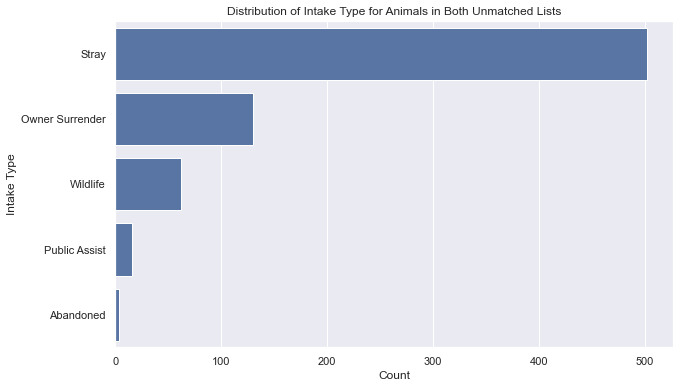

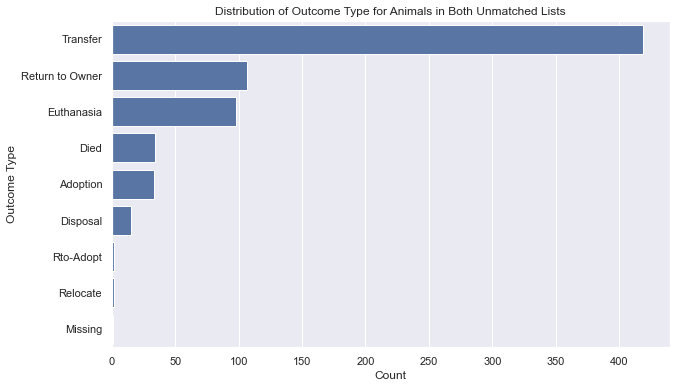

In [21]:
# Filter the original intakes and outcomes dataframes for the animal IDs found in both unmatched lists
intakes_in_both_unmatched = intakes_df[intakes_df['Animal ID'].isin(animal_ids_in_both_unmatched)]
outcomes_in_both_unmatched = outcomes_df_filtered[outcomes_df_filtered['Animal ID'].isin(animal_ids_in_both_unmatched)]

# Visualize the distribution of Intake Type for these animals
plt.figure(figsize=(10, 6))
sns.countplot(data=intakes_in_both_unmatched, y='Intake Type', order=intakes_in_both_unmatched['Intake Type'].value_counts().index)
plt.title('Distribution of Intake Type for Animals in Both Unmatched Lists')
plt.xlabel('Count')
plt.ylabel('Intake Type')
plt.show()

# Visualize the distribution of Outcome Type for these animals
plt.figure(figsize=(10, 6))
sns.countplot(data=outcomes_in_both_unmatched, y='Outcome Type', order=outcomes_in_both_unmatched['Outcome Type'].value_counts().index)
plt.title('Distribution of Outcome Type for Animals in Both Unmatched Lists')
plt.xlabel('Count')
plt.ylabel('Outcome Type')
plt.show()

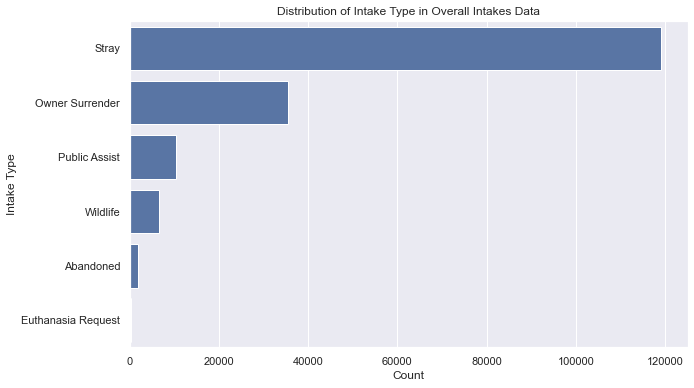

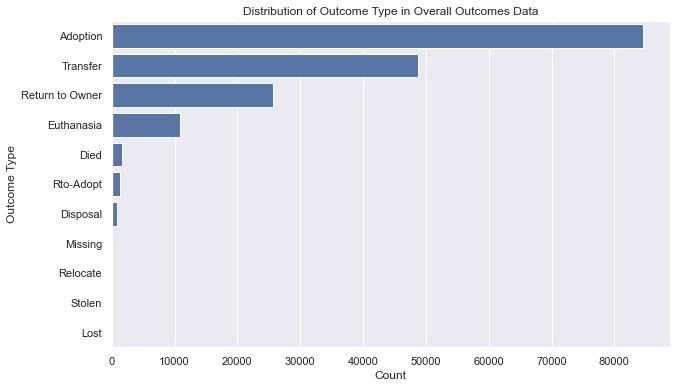

In [22]:
# Visualize the distribution of Intake Type for the overall intakes_df
plt.figure(figsize=(10, 6))
sns.countplot(data=intakes_df, y='Intake Type', order=intakes_df['Intake Type'].value_counts().index)
plt.title('Distribution of Intake Type in Overall Intakes Data')
plt.xlabel('Count')
plt.ylabel('Intake Type')
plt.show()

# Visualize the distribution of Outcome Type for the overall outcomes_df
plt.figure(figsize=(10, 6))
sns.countplot(data=outcomes_df, y='Outcome Type', order=outcomes_df['Outcome Type'].value_counts().index)
plt.title('Distribution of Outcome Type in Overall Outcomes Data')
plt.xlabel('Count')
plt.ylabel('Outcome Type')
plt.show()

# Addressing Outliers:



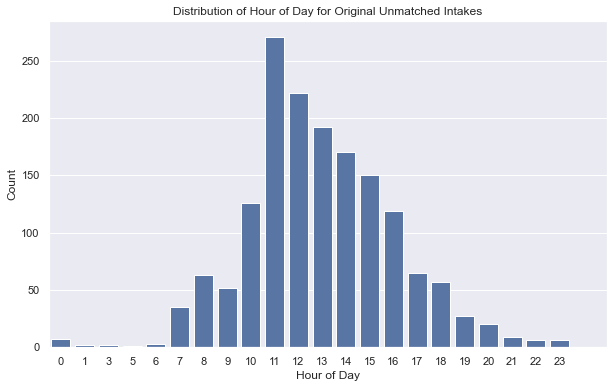

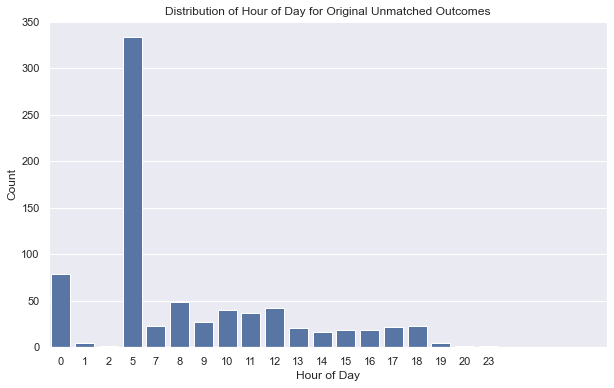

In [23]:
# Extract the hour of the day for the original unmatched intakes and outcomes
unmatched_intakes_df['Hour'] = unmatched_intakes_df['DateTime'].dt.hour
unmatched_outcomes_df['Hour'] = unmatched_outcomes_df['DateTime'].dt.hour

# Visualize the distribution of the hour of the day for original unmatched intakes
plt.figure(figsize=(10, 6))
sns.countplot(data=unmatched_intakes_df, x='Hour', order=sorted(unmatched_intakes_df['Hour'].unique()))
plt.title('Distribution of Hour of Day for Original Unmatched Intakes')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.xticks(np.arange(0, 24))
plt.show()

# Visualize the distribution of the hour of the day for original unmatched outcomes
plt.figure(figsize=(10, 6))
sns.countplot(data=unmatched_outcomes_df, x='Hour', order=sorted(unmatched_outcomes_df['Hour'].unique()))
plt.title('Distribution of Hour of Day for Original Unmatched Outcomes')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.xticks(np.arange(0, 24))
plt.show()

Based on observed data, I hypothesize that there are missing episodes due to incorrectly labeled times for outcomes. In the data, there are 638 unique Animal IDs that have at least one entry in both the unmatched_intakes_df and the unmatched_outcomes_df. Some can be resolved if we fix the outcome times for the cases where the outcome times are before the intake times.

I'm going to identify all mismatched outcome entries that have a corresponding mismatched intake Animal ID with a defaulted time of 5 am and change them to 11:59 pm.

In [24]:
# Filter unmatched outcomes for the Animal IDs that are also in unmatched intakes
unmatched_outcomes_in_both = unmatched_outcomes_df[unmatched_outcomes_df['Animal ID'].isin(animal_ids_in_both_unmatched)].copy()

# Extract the time component and check for '05:00:00'
time_05_00_00_count = (unmatched_outcomes_in_both['DateTime'].dt.time == pd.to_datetime('05:00:00').time()).sum()

print(f"Number of unmatched outcome records with time 05:00:00 for animals in both unmatched lists: {time_05_00_00_count}")

# Optionally, display some of these records
if time_05_00_00_count > 0:
    print("\nSample of unmatched outcome records with time 05:00:00 (first 5):")
    display(unmatched_outcomes_in_both[unmatched_outcomes_in_both['DateTime'].dt.time == pd.to_datetime('05:00:00').time()].head())

Number of unmatched outcome records with time 05:00:00 for animals in both unmatched lists: 332

Sample of unmatched outcome records with time 05:00:00 (first 5):


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color,Hour
0,A006100,2007-07-09,Scamp,2017-12-07 05:00:00,12-2017,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White,5
3,A531969,2008-03-06,Black,2015-11-13 05:00:00,11-2015,Return to Owner,NaN,Dog,Neutered Male,7 years,Pit Bull Mix,Black/White,5
4,A533243,2008-07-15,Choco,2016-12-20 05:00:00,12-2016,Return to Owner,NaN,Dog,Neutered Male,8 years,Labrador Retriever/Pit Bull,Chocolate,5
5,A554047,2009-07-08,Mega,2016-05-14 05:00:00,05-2016,Return to Owner,NaN,Dog,Neutered Male,6 years,Pit Bull Mix,Brown/White,5
8,A587232,2009-10-19,Rosie,2022-02-01 05:00:00,02-2022,Return to Owner,Field,Dog,Spayed Female,12 years,Chihuahua Shorthair Mix,Black/White,5


In [25]:
# Create a copy of the outcomes_df_filtered DataFrame
outcomes_df_adjusted = outcomes_df_filtered.copy()

# Identify the indices of the outcome records with time 05:00:00 in the copied DataFrame
indices_to_modify_adjusted = outcomes_df_adjusted[outcomes_df_adjusted['DateTime'].dt.time == pd.to_datetime('05:00:00').time()].index

# Change the time component of the 'DateTime' column to 23:59:00 for these records in the copied DataFrame
outcomes_df_adjusted.loc[indices_to_modify_adjusted, 'DateTime'] = outcomes_df_adjusted.loc[indices_to_modify_adjusted, 'DateTime'].apply(lambda dt: dt.replace(hour=23, minute=59, second=0))

print("Outcomes DataFrame with adjusted timestamps (first 5 with original 05:00:00 time):")
display(outcomes_df_adjusted.loc[indices_to_modify_adjusted].head())

Outcomes DataFrame with adjusted timestamps (first 5 with original 05:00:00 time):


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
1891,A006100,2007-07-09,Scamp,2017-12-07 23:59:00,12-2017,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
300,A433746,2006-04-09,Evette,2015-11-04 23:59:00,11-2015,Transfer,Partner,Dog,Spayed Female,9 years,Australian Shepherd Mix,White/Brown
2080,A458233,2006-01-12,Cinnamon,2018-06-08 23:59:00,06-2018,Euthanasia,At Vet,Dog,Spayed Female,12 years,Beagle Mix,Tricolor
72,A459161,2006-01-27,Dugan,2015-04-19 23:59:00,04-2015,Return to Owner,NaN,Dog,Neutered Male,9 years,Shih Tzu Mix,Black/White
1603,A465637,2007-01-11,*Commander,2017-06-20 23:59:00,06-2017,Transfer,Partner,Dog,Neutered Male,10 years,Pit Bull,Chocolate/White


### Replicate Visit Creation with Adjusted Data


Replicate the episode creation logic using the original `intakes_df` and the `outcomes_df_adjusted` DataFrame.

In [26]:
grouped_intakes_new = intakes_df.groupby('Animal ID')
grouped_outcomes_adjusted = outcomes_df_adjusted.groupby('Animal ID')

visits_adjusted = []
unmatched_intakes_adjusted = []
unmatched_outcomes_adjusted = []

for animal_id, intake_group in grouped_intakes_new:
    intake_records = intake_group.to_dict('records')
    outcome_records = grouped_outcomes_adjusted.get_group(animal_id).to_dict('records') if animal_id in grouped_outcomes_adjusted.groups else []

    used_outcomes_indices = set()

    for intake in intake_records:
        matched_outcome = None
        # Find the first outcome after the intake date that hasn't been used
        for i, outcome in enumerate(outcome_records):
            if i not in used_outcomes_indices and outcome['DateTime'] >= intake['DateTime']:
                matched_outcome = outcome
                used_outcomes_indices.add(i)
                break

        if matched_outcome:
            visit = {
                'Animal ID': animal_id,
                'Intake': intake,
                'Outcome': matched_outcome
            }
            visits_adjusted.append(visit)
        else:
            unmatched_intakes_adjusted.append(intake)

    # Check for any outcomes that were not matched with an intake
    for i, outcome in enumerate(outcome_records):
        if i not in used_outcomes_indices:
            unmatched_outcomes_adjusted.append(outcome)

print(f"Number of episodes created with adjusted data: {len(visits_adjusted)}")
print(f"Number of unmatched intakes with adjusted data: {len(unmatched_intakes_adjusted)}")
print(f"Number of unmatched outcomes with adjusted data: {len(unmatched_outcomes_adjusted)}")

Number of episodes created with adjusted data: 172502
Number of unmatched intakes with adjusted data: 1274
Number of unmatched outcomes with adjusted data: 433


### Store Visits and Identify Remaining Mismatches (Adjusted Data)

In [27]:
# Store the created visits with adjusted data in a new DataFrame and identify any remaining mismatches
visit_list_adjusted = []

for visit in visits_adjusted:
    intake_details = visit['Intake']
    outcome_details = visit['Outcome']

    # Extract relevant information from intake and outcome records
    visit_data = {
        'Animal ID': visit['Animal ID'],
        'Intake_DateTime': intake_details['DateTime'],
        'Intake_Type': intake_details['Intake Type'],
        'Intake_Condition': intake_details['Intake Condition'],
        'Intake_Animal_Type': intake_details['Animal Type'],
        'Intake_Sex': intake_details['Sex upon Intake'],
        'Intake_Age': intake_details['Age upon Intake'],
        'Intake_Breed': intake_details['Breed'],
        'Intake_Color': intake_details['Color'],
        'Outcome_DateTime': outcome_details['DateTime'] if outcome_details else None,
        'Outcome_Type': outcome_details['Outcome Type'] if outcome_details else None,
        'Outcome_Subtype': outcome_details['Outcome Subtype'] if outcome_details else None,
        'Outcome_Animal_Type': outcome_details['Animal Type'] if outcome_details else None,
        'Outcome_Sex': outcome_details['Sex upon Outcome'] if outcome_details else None,
        'Outcome_Age': outcome_details['Age upon Outcome'] if outcome_details else None,
        'Outcome_Breed': outcome_details['Breed'] if outcome_details else None,
        'Outcome_Color': outcome_details['Color'] if outcome_details else None,
    }

    # Calculate duration of stay
    if visit_data['Outcome_DateTime'] is not None:
        visit_data['duration_of_stay'] = (visit_data['Outcome_DateTime'] - visit_data['Intake_DateTime']).total_seconds() / (24 * 3600)
    else:
        visit_data['duration_of_stay'] = None


    visit_list_adjusted.append(visit_data)

# Convert the list of dictionaries to a DataFrame
visits_df_adjusted = pd.DataFrame(visit_list_adjusted)

# Convert unmatched lists to DataFrames for easier analysis
unmatched_intakes_df_adjusted = pd.DataFrame(unmatched_intakes_adjusted)
unmatched_outcomes_df_adjusted = pd.DataFrame(unmatched_outcomes_adjusted)


print("Visits DataFrame with adjusted data:")
display(visits_df_adjusted.head())
print("\nNumber of unmatched intakes with adjusted data:")
display(len(unmatched_intakes_df_adjusted))
print("\nNumber of unmatched outcomes with adjusted data:")
display(len(unmatched_outcomes_df_adjusted))

Visits DataFrame with adjusted data:


,Animal ID,Intake_DateTime,Intake_Type,Intake_Condition,Intake_Animal_Type,Intake_Sex,Intake_Age,Intake_Breed,Intake_Color,Outcome_DateTime,Outcome_Type,Outcome_Subtype,Outcome_Animal_Type,Outcome_Sex,Outcome_Age,Outcome_Breed,Outcome_Color,duration_of_stay
0,A006100,2014-03-07 14:26:00,Public Assist,Normal,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White,2014-03-08 17:10:00,Return to Owner,NaN,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White,1.11
1,A006100,2014-12-19 10:21:00,Public Assist,Normal,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White,2014-12-20 16:35:00,Return to Owner,NaN,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White,1.26
2,A006100,2017-12-07 14:07:00,Stray,Normal,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White,2017-12-07 23:59:00,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White,0.41
3,A047759,2014-04-02 15:55:00,Owner Surrender,Normal,Dog,Neutered Male,10 years,Dachshund,Tricolor,2014-04-07 15:12:00,Transfer,Partner,Dog,Neutered Male,10 years,Dachshund,Tricolor,4.97
4,A134067,2013-11-16 09:02:00,Public Assist,Injured,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White,2013-11-16 11:54:00,Return to Owner,NaN,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White,0.12



Number of unmatched intakes with adjusted data:


1274


Number of unmatched outcomes with adjusted data:


433

Reduction in Unmatched Intakes: 1605 - 1274 = 331
Reduction in Unmatched Outcomes: 764 - 433 = 331

Adjusting the 332 outcome timestamps from 05:00:00 to 23:59:00 resulted in 331 fewer unmatched intake records.

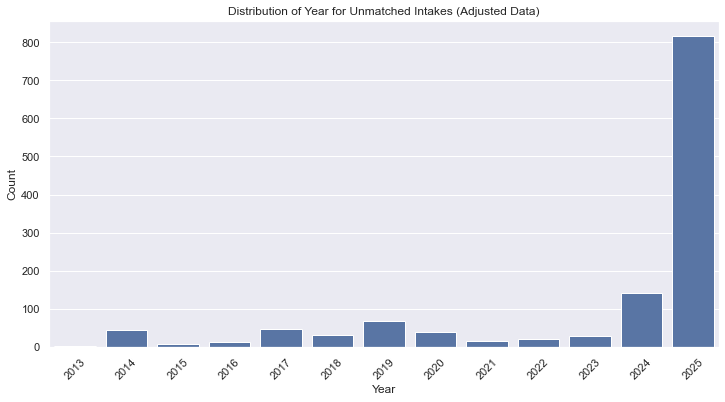

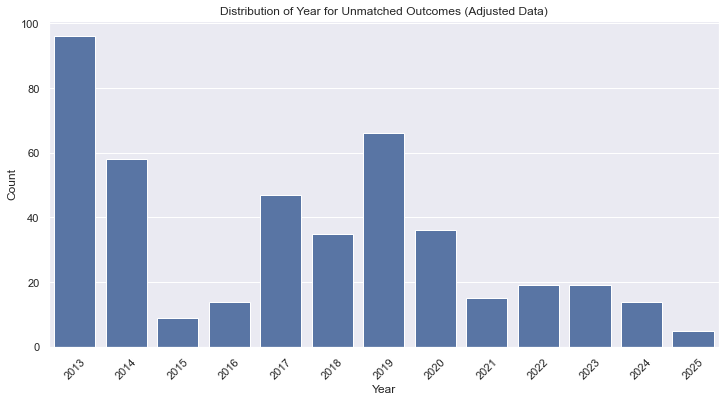

In [28]:
# Extract the year for unmatched intakes and outcomes
unmatched_intakes_df_adjusted['Year'] = unmatched_intakes_df_adjusted['DateTime'].dt.year
unmatched_outcomes_df_adjusted['Year'] = unmatched_outcomes_df_adjusted['DateTime'].dt.year

# Visualize the distribution of the year for unmatched intakes
plt.figure(figsize=(12, 6))
sns.countplot(data=unmatched_intakes_df_adjusted, x='Year', order=sorted(unmatched_intakes_df_adjusted['Year'].unique()))
plt.title('Distribution of Year for Unmatched Intakes (Adjusted Data)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Visualize the distribution of the year for unmatched outcomes
plt.figure(figsize=(12, 6))
sns.countplot(data=unmatched_outcomes_df_adjusted, x='Year', order=sorted(unmatched_outcomes_df_adjusted['Year'].unique()))
plt.title('Distribution of Year for Unmatched Outcomes (Adjusted Data)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [29]:
unmatched_outcomes_2013 = unmatched_outcomes_df_adjusted[unmatched_outcomes_df_adjusted['Year'] == 2013]
count_unmatched_outcomes_2013 = len(unmatched_outcomes_2013)

print(f"Number of unmatched outcomes from 2013 (adjusted data): {count_unmatched_outcomes_2013}")


unmatched_intakes_2025 = unmatched_intakes_df_adjusted[unmatched_intakes_df_adjusted['Year'] == 2025]
count_unmatched_intakes_2025 = len(unmatched_intakes_2025)

print(f"Number of unmatched intakes from 2025 (adjusted data): {count_unmatched_intakes_2025}")


total_unmatched_intakes_adjusted = len(unmatched_intakes_df_adjusted)
total_unmatched_outcomes_adjusted = len(unmatched_outcomes_df_adjusted)
total_unmatched_combined_adjusted = total_unmatched_intakes_adjusted + total_unmatched_outcomes_adjusted

print(f"Total unmatched intakes (adjusted data): {total_unmatched_intakes_adjusted}")
print(f"Total unmatched outcomes (adjusted data): {total_unmatched_outcomes_adjusted}")
print(f"Total unmatched combined (adjusted data): {total_unmatched_combined_adjusted}")


percentage_2013_outcomes = (count_unmatched_outcomes_2013 / total_unmatched_outcomes_adjusted) * 100 if total_unmatched_outcomes_adjusted > 0 else 0

print(f"\nPercentage of 2013 unmatched outcomes from total unmatched outcomes: {percentage_2013_outcomes:.2f}%")


percentage_2025_intakes = (count_unmatched_intakes_2025 / total_unmatched_intakes_adjusted) * 100 if total_unmatched_intakes_adjusted > 0 else 0
print(f"Percentage of 2025 unmatched intakes from total unmatched intakes: {percentage_2025_intakes:.2f}%")

percentage_combined_edge_cases = ((count_unmatched_outcomes_2013 + count_unmatched_intakes_2025) / total_unmatched_combined_adjusted) * 100 if total_unmatched_combined_adjusted > 0 else 0
print(f"Percentage of 2013 unmatched outcomes and 2025 unmatched intakes from total unmatched combined: {percentage_combined_edge_cases:.2f}%")

Number of unmatched outcomes from 2013 (adjusted data): 96
Number of unmatched intakes from 2025 (adjusted data): 816
Total unmatched intakes (adjusted data): 1274
Total unmatched outcomes (adjusted data): 433
Total unmatched combined (adjusted data): 1707

Percentage of 2013 unmatched outcomes from total unmatched outcomes: 22.17%
Percentage of 2025 unmatched intakes from total unmatched intakes: 64.05%
Percentage of 2013 unmatched outcomes and 2025 unmatched intakes from total unmatched combined: 53.43%


In [30]:
# Find Animal IDs that exist in both unmatched_intakes_df_adjusted and unmatched_outcomes_df_adjusted
animal_ids_in_both_unmatched_adjusted = pd.merge(unmatched_intakes_df_adjusted['Animal ID'], unmatched_outcomes_df_adjusted['Animal ID'], on='Animal ID', how='inner')['Animal ID'].unique()

print("Animal IDs that appear in both unmatched intakes and unmatched outcomes (adjusted data):")
print(animal_ids_in_both_unmatched_adjusted)
print(f"\nNumber of Animal IDs in both unmatched dataframes (adjusted data): {len(animal_ids_in_both_unmatched_adjusted)}")

# Take a sample of these Animal IDs
sample_animal_ids_adjusted = np.random.choice(animal_ids_in_both_unmatched_adjusted, size=10, replace=False)

print("\nInvestigating sample Animal IDs with entries in both unmatched lists (adjusted data):")
for animal_id in sample_animal_ids_adjusted:
    print(f"\n--- Entries for Animal ID: {animal_id} ---")

    # Display entries from the sorted intakes_df
    print("\nIntake entries:")
    display(intakes_df[intakes_df['Animal ID'] == animal_id])

    # Display entries from the outcomes_df_adjusted (with adjusted timestamps)
    print("\nOutcome entries:")
    display(outcomes_df_adjusted[outcomes_df_adjusted['Animal ID'] == animal_id])

Animal IDs that appear in both unmatched intakes and unmatched outcomes (adjusted data):
['A624094' 'A659667' 'A665649' 'A672696' 'A674638' 'A675125' 'A675480'
 'A676345' 'A678461' 'A678823' 'A678824' 'A679180' 'A679181' 'A679182'
 'A679215' 'A679217' 'A679222' 'A679305' 'A679357' 'A679361' 'A679408'
 'A679940' 'A679980' 'A680032' 'A680057' 'A680058' 'A680106' 'A680138'
 'A680141' 'A680144' 'A680319' 'A680504' 'A680744' 'A681049' 'A681851'
 'A681854' 'A681856' 'A681857' 'A681858' 'A681860' 'A681862' 'A681863'
 'A681864' 'A684858' 'A697081' 'A702081' 'A702786' 'A703445' 'A706446'
 'A711562' 'A711688' 'A716272' 'A717220' 'A718498' 'A718535' 'A721052'
 'A721112' 'A722153' 'A726746' 'A726749' 'A728301' 'A730626' 'A733964'
 'A734950' 'A737741' 'A738466' 'A738994' 'A739532' 'A742322' 'A742340'
 'A742708' 'A742796' 'A743544' 'A743548' 'A743708' 'A746851' 'A746983'
 'A747192' 'A747201' 'A747202' 'A748513' 'A751607' 'A753148' 'A755110'
 'A757613' 'A757614' 'A757615' 'A757616' 'A757618' 'A757652

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
152947,A883802,NaN,2023-06-23 16:31:00,June 2023,6910 Dubuque Ln in Austin (TX),Wildlife,Sick,Other,Unknown,2 years,Raccoon,Black/Gray



Outcome entries:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
152943,A883802,2021-06-23,NaN,2023-06-23,06-2023,Euthanasia,NaN,Other,Unknown,2 years,Raccoon,Black/Gray



--- Entries for Animal ID: A818512 ---

Intake entries:


...

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
117835,A815755,2019-03-24,NaN,2020-03-24 09:49:00,03-2020,Disposal,NaN,Other,Unknown,1 year,Bat,Brown



--- Entries for Animal ID: A757613 ---

Intake entries:


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
71668,A757613,NaN,2017-09-04 14:21:00,September 2017,6105 Jacqueline Ln in Austin (TX),Stray,Sick,Cat,Intact Male,2 weeks,Domestic Shorthair Mix,Orange Tabby



Outcome entries:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
72222,A757613,2017-08-20,NaN,2017-09-04 08:50:00,09-2017,Transfer,Partner,Cat,Intact Male,2 weeks,Domestic Shorthair Mix,Orange Tabby


In [31]:
# Create copies of the adjusted unmatched dataframes
unmatched_intakes_df_final = unmatched_intakes_df_adjusted.copy()
unmatched_outcomes_df_final = unmatched_outcomes_df_adjusted.copy()

# Identify animal IDs that are in both unmatched dataframes (from adjusted data)
animal_ids_in_both_unmatched_adjusted = unmatched_intakes_df_final[unmatched_intakes_df_final['Animal ID'].isin(unmatched_outcomes_df_final['Animal ID'])]['Animal ID'].unique()

# Filter unmatched intakes and outcomes for these animal IDs
intakes_to_recheck = unmatched_intakes_df_final[unmatched_intakes_df_final['Animal ID'].isin(animal_ids_in_both_unmatched_adjusted)].copy()
outcomes_to_recheck = unmatched_outcomes_df_final[unmatched_outcomes_df_final['Animal ID'].isin(animal_ids_in_both_unmatched_adjusted)].copy()

# Adjust outcome times to 23:59:00 if the intake and outcome dates are the same
for index, outcome_row in outcomes_to_recheck.iterrows():
    animal_id = outcome_row['Animal ID']
    matching_intakes = intakes_to_recheck[(intakes_to_recheck['Animal ID'] == animal_id) & (intakes_to_recheck['DateTime'].dt.date == outcome_row['DateTime'].date())]

    if not matching_intakes.empty:
        outcomes_to_recheck.loc[index, 'DateTime'] = outcome_row['DateTime'].replace(hour=23, minute=59, second=0)

unmatched_outcomes_df_final.loc[outcomes_to_recheck.index, 'DateTime'] = outcomes_to_recheck['DateTime']


# Re-attempt to match records with adjusted outcome times
re_grouped_intakes = intakes_to_recheck.groupby('Animal ID')
re_grouped_outcomes = outcomes_to_recheck.groupby('Animal ID')

newly_matched_visits = []
still_unmatched_intakes = []
still_unmatched_outcomes = []


for animal_id, intake_group in re_grouped_intakes:
    intake_records = intake_group.to_dict('records')
    outcome_records = re_grouped_outcomes.get_group(animal_id).to_dict('records') if animal_id in re_grouped_outcomes.groups else []

    used_outcomes_indices = set()

    for intake in intake_records:
        matched_outcome = None
        # Find the first outcome after the intake date that hasn't been used
        for i, outcome in enumerate(outcome_records):
            if i not in used_outcomes_indices and outcome['DateTime'] >= intake['DateTime']:
                matched_outcome = outcome
                used_outcomes_indices.add(i)
                break

        if matched_outcome:
            newly_matched_visits.append({'Intake': intake, 'Outcome': matched_outcome})
        else:
            still_unmatched_intakes.append(intake)

    # Check for any outcomes that were not matched with an intake
    for i, outcome in enumerate(outcome_records):
        if i not in used_outcomes_indices:
            still_unmatched_outcomes.append(outcome)


# Update the final unmatched dataframes by removing the newly matched records
matched_intake_animal_ids = [visit['Intake']['Animal ID'] for visit in newly_matched_visits]
matched_intake_datetimes = [visit['Intake']['DateTime'] for visit in newly_matched_visits]
matched_outcome_animal_ids = [visit['Outcome']['Animal ID'] for visit in newly_matched_visits]
matched_outcome_datetimes = [visit['Outcome']['DateTime'] for visit in newly_matched_visits]


# Create a boolean mask for rows to keep in unmatched_intakes_df_final
mask_intakes_to_keep = ~unmatched_intakes_df_final.apply(
    lambda row: any((row['Animal ID'] == aid) and (row['DateTime'] == dt) for aid, dt in zip(matched_intake_animal_ids, matched_intake_datetimes)), axis=1
)
unmatched_intakes_df_final = unmatched_intakes_df_final[mask_intakes_to_keep].copy()

# Create a boolean mask for rows to keep in unmatched_outcomes_df_final
mask_outcomes_to_keep = ~unmatched_outcomes_df_final.apply(
    lambda row: any((row['Animal ID'] == aid) and (row['DateTime'] == dt) for aid, dt in zip(matched_outcome_animal_ids, matched_outcome_datetimes)), axis=1
)
unmatched_outcomes_df_final = unmatched_outcomes_df_final[mask_outcomes_to_keep].copy()


print(f"Number of newly matched visits: {len(newly_matched_visits)}")
print(f"Number of remaining unmatched intakes (final): {len(unmatched_intakes_df_final)}")
print(f"Number of remaining unmatched outcomes (final): {len(unmatched_outcomes_df_final)}")

print("\nFirst 5 rows of unmatched intakes (final):")
display(unmatched_intakes_df_final.head())

print("\nFirst 5 rows of unmatched outcomes (final):")
display(unmatched_outcomes_df_final.head())

Number of newly matched visits: 298
Number of remaining unmatched intakes (final): 976
Number of remaining unmatched outcomes (final): 135

First 5 rows of unmatched intakes (final):


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color,Year
1,A636629,NaN,2014-09-07 16:31:00,September 2014,706 Terrace Mountain Drive in Austin (TX),Stray,Normal,Cat,Spayed Female,4 years,Domestic Shorthair Mix,Tortie,2014
2,A645513,NaN,2015-05-18 07:30:00,May 2015,3001 Sauls in Austin (TX),Stray,Injured,Cat,Neutered Male,6 years,Domestic Longhair Mix,Cream Tabby/White,2015
35,A681049,Patty,2019-04-30 07:15:00,April 2019,4434 Frontier Trail in Austin (TX),Owner Surrender,Injured,Dog,Spayed Female,7 years,German Shepherd Mix,Brown/Black,2019
45,A682781,NaN,2014-08-13 18:41:00,August 2014,Colorado & 6Th Street in Austin (TX),Stray,Normal,Cat,Neutered Male,1 year,Domestic Shorthair Mix,White/Black,2014
46,A683782,NaN,2014-07-19 15:55:00,July 2014,11411 Research Blvd in Austin (TX),Stray,Normal,Cat,Neutered Male,5 months,Domestic Shorthair Mix,Brown Tabby,2014



First 5 rows of unmatched outcomes (final):


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color,Year
0,A483240,2007-06-17,Frassina,2013-11-16 15:58:00,11-2013,Adoption,NaN,Cat,Spayed Female,6 years,Domestic Longhair/Persian,Blue Cream,2013
1,A531739,2008-02-29,Bentley,2013-11-30 13:31:00,11-2013,Adoption,NaN,Dog,Neutered Male,5 years,Pointer Mix,White/Tan,2013
2,A556804,2002-02-05,Kathy,2013-11-16 16:38:00,11-2013,Adoption,NaN,Cat,Spayed Female,11 years,Domestic Shorthair Mix,Black/White,2013
3,A561806,2008-11-30,Dasia,2017-06-05 18:09:00,06-2017,Return to Owner,NaN,Dog,Spayed Female,8 years,Pit Bull Mix,Brown Brindle/White,2017
4,A601869,2011-04-10,Otto,2013-10-10 12:00:00,10-2013,Transfer,Partner,Cat,Neutered Male,2 years,Domestic Shorthair Mix,Black,2013


Reduction in Unmatched Intakes: 1274 - 976 = 298
Reduction in Unmatched Outcomes: 433 - 135 = 298

Adjusting the 298 outcome timestamps to 23:59:00 resulted in 298 fewer unmatched intake records and outcome records.

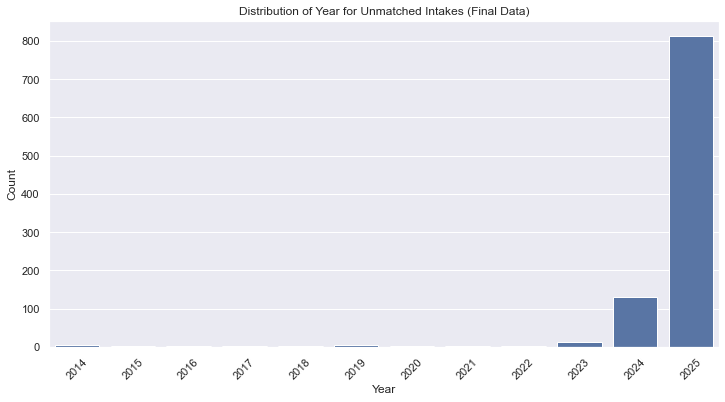

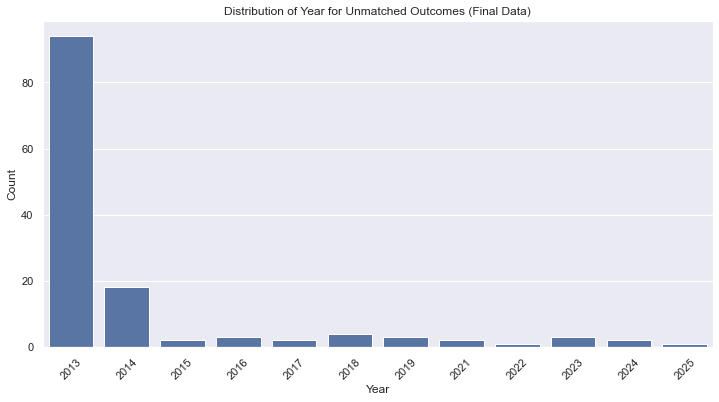

In [32]:
# Extract the year for unmatched intakes and outcomes
unmatched_intakes_df_final['Year'] = unmatched_intakes_df_final['DateTime'].dt.year
unmatched_outcomes_df_final['Year'] = unmatched_outcomes_df_final['DateTime'].dt.year

# Visualize the distribution of the year for unmatched intakes
plt.figure(figsize=(12, 6))
sns.countplot(data=unmatched_intakes_df_final, x='Year', order=sorted(unmatched_intakes_df_final['Year'].unique()))
plt.title('Distribution of Year for Unmatched Intakes (Final Data)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Visualize the distribution of the year for unmatched outcomes
plt.figure(figsize=(12, 6))
sns.countplot(data=unmatched_outcomes_df_final, x='Year', order=sorted(unmatched_outcomes_df_final['Year'].unique()))
plt.title('Distribution of Year for Unmatched Outcomes (Final Data)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [33]:
# Build visits_final from your prior visits plus the newly matched ones
visits_base = []
if 'visits_adjusted' in globals():
    visits_base = list(visits_adjusted)
elif 'visits' in globals():
    visits_base = list(visits)
else:
    visits_base = []

visits_final = list(visits_base) + list(newly_matched_visits)

# Create visit_list_final mirroring visit_list / visit_list_adjusted schema
visit_list_final = []

for visit in visits_final:
    intake_details = visit['Intake']
    outcome_details = visit.get('Outcome', None)

    # Most robust way to get Animal ID
    animal_id = visit.get('Animal ID', intake_details.get('Animal ID', None))

    visit_data = {
        'Animal ID': animal_id,
        'Intake_DateTime': intake_details['DateTime'],
        'Intake_Type': intake_details.get('Intake Type'),
        'Intake_Name': intake_details.get('Name'),
        'Intake_Condition': intake_details.get('Intake Condition'),
        'Intake_Animal_Type': intake_details.get('Animal Type'),
        'Intake_Sex': intake_details.get('Sex upon Intake'),
        'Intake_Age': intake_details.get('Age upon Intake'),
        'Intake_Breed': intake_details.get('Breed'),
        'Intake_Color': intake_details.get('Color'),
        'Outcome_Name': outcome_details.get('Name') if outcome_details else None,
        'Outcome_DateTime': outcome_details['DateTime'] if outcome_details else None,
        'Outcome_Type': outcome_details.get('Outcome Type') if outcome_details else None,
        'Outcome_Subtype': outcome_details.get('Outcome Subtype') if outcome_details else None,
        'Outcome_Animal_Type': outcome_details.get('Animal Type') if outcome_details else None,
        'Outcome_Sex': outcome_details.get('Sex upon Outcome') if outcome_details else None,
        'Outcome_Age': outcome_details.get('Age upon Outcome') if outcome_details else None,
        'Outcome_Breed': outcome_details.get('Breed') if outcome_details else None,
        'Outcome_Color': outcome_details.get('Color') if outcome_details else None,
    }

    # Duration of stay
    if visit_data['Outcome_DateTime'] is not None:
        visit_data['duration_of_stay'] = visit_data['Outcome_DateTime'] - visit_data['Intake_DateTime']
    else:
        visit_data['duration_of_stay'] = None

    visit_list_final.append(visit_data)

print(f"Visits base count: {len(visits_base)}")
print(f"Newly matched added: {len(newly_matched_visits)}")
print(f"visit_list_final total: {len(visit_list_final)}")


Visits base count: 172502
Newly matched added: 298
visit_list_final total: 172800


In [34]:
unmatched_intakes_df_final = pd.DataFrame(still_unmatched_intakes)
unmatched_outcomes_df_final = pd.DataFrame(still_unmatched_outcomes)

# Keep DateTime dtype + ordering consistent with earlier cells
for df in (unmatched_intakes_df_final, unmatched_outcomes_df_final):
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    if 'Animal ID' in df.columns and 'DateTime' in df.columns:
        df.sort_values(by=['Animal ID', 'DateTime'], inplace=True)

print(f"Number of remaining unmatched intakes (final): {len(unmatched_intakes_df_final)}")
print(f"Number of remaining unmatched outcomes (final): {len(unmatched_outcomes_df_final)}")

print("\nUnmatched intakes (final):")
display(unmatched_intakes_df_final.head(9))

print("\nUnmatched outcomes (final):")
display(unmatched_outcomes_df_final.head(9))

Number of remaining unmatched intakes (final): 9
Number of remaining unmatched outcomes (final): 9

Unmatched intakes (final):


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color,Year
0,A681049,Patty,2019-04-30 07:15:00,April 2019,4434 Frontier Trail in Austin (TX),Owner Surrender,Injured,Dog,Spayed Female,7 years,German Shepherd Mix,Brown/Black,2019
1,A718498,Snoop Dog,2016-01-02 14:08:00,January 2016,6807 Wentworth Dr in Austin (TX),Owner Surrender,Injured,Dog,Intact Male,1 year,Labrador Retriever Mix,Black,2016
2,A721112,Bella,2016-11-19 18:39:00,November 2016,Montana St And Vasquez St in Austin (TX),Stray,Normal,Dog,Spayed Female,10 years,Australian Cattle Dog Mix,White/Tan,2016
3,A730626,Buster,2018-02-08 16:12:00,February 2018,Grayson Ln in Austin (TX),Stray,Injured,Dog,Intact Male,3 years,Pit Bull Mix,Brown/White,2018
4,A733964,Niko,2020-02-14 14:33:00,February 2020,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,5 years,German Shepherd,Black/Brown,2020
5,A753148,Dandelion,2019-07-09 17:06:00,July 2019,Austin (TX),Owner Surrender,Sick,Cat,Intact Female,13 years,Domestic Shorthair Mix,Torbie,2019
6,A766554,Roxy,2020-03-01 11:51:00,March 2020,Austin (TX),Owner Surrender,Normal,Dog,Spayed Female,3 years,German Shepherd,Black/Brown,2020
7,A788114,Luu,2019-04-01 11:57:00,April 2019,8515 Brodie Lane 2127 in Austin (TX),Stray,Normal,Dog,Intact Female,8 months,Beagle/German Shepherd,Black/Tan,2019
8,A807087,Opera,2019-12-02 11:59:00,December 2019,Aldea Drive And Matthews Lane in Austin (TX),Stray,Normal,Dog,Intact Female,3 years,Pit Bull,Red/White,2019



Unmatched outcomes (final):


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color,Year
0,A681049,2011-12-11,Patty,2019-01-12 15:17:33,01-2019,Transfer,Partner,Dog,Intact Female,7 years,German Shepherd Mix,Brown/Black,2019
1,A718498,2014-07-01,Snoop Dog,2015-12-31 14:04:00,12-2015,Return to Owner,NaN,Dog,Intact Male,1 year,Labrador Retriever Mix,Black,2015
2,A721112,2006-02-22,Bella,2016-02-22 12:47:00,02-2016,Return to Owner,NaN,Dog,Spayed Female,10 years,Australian Cattle Dog Mix,White/Tan,2016
3,A730626,2014-07-07,Buster,2016-07-24 19:25:00,07-2016,Return to Owner,NaN,Dog,Intact Male,2 years,Pit Bull Mix,Brown/White,2016
4,A733964,2014-08-30,Niko,2018-02-11 10:50:00,02-2018,Return to Owner,NaN,Dog,Intact Male,3 years,German Shepherd,Black/Brown,2018
5,A753148,2005-11-02,Dandelion,2018-10-18 11:26:00,10-2018,Return to Owner,NaN,Cat,Intact Female,12 years,Domestic Shorthair Mix,Torbie,2018
6,A766554,2017-02-11,Roxy,2018-02-11 10:50:00,02-2018,Return to Owner,NaN,Dog,Intact Female,1 year,German Shepherd,Black/Brown,2018
7,A788114,2018-07-26,Luu,2019-02-07 11:35:00,02-2019,Return to Owner,NaN,Dog,Intact Female,6 months,Beagle/German Shepherd,Black/Tan,2019
8,A807087,2016-10-20,Opera,2019-10-20 11:11:00,10-2019,Return to Owner,NaN,Dog,Intact Female,3 years,Pit Bull,Red/White,2019




## Finalize Visit data with more additional preprocessing




In [35]:
# Create a new DataFrame from the visit_list
final_df = pd.DataFrame(visit_list_final)

In [36]:
# Show samples where Intake_Sex and Outcome_Sex differ (case/whitespace-insensitive)
mask = final_df['Intake_Sex'].notna() & final_df['Outcome_Sex'].notna()
si = final_df.loc[mask, 'Intake_Sex'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
so = final_df.loc[mask, 'Outcome_Sex'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
diff = si != so

print(f"Differing rows: {int(diff.sum())}\n")

print("Top differing pairs:")
print(pd.DataFrame({'Intake_Sex_norm': si[diff], 'Outcome_Sex_norm': so[diff]})
        .value_counts()
        .head(10))

print("\nSample rows:")
print(final_df.loc[mask & diff, ['Animal ID','Intake_DateTime','Outcome_DateTime','Intake_Sex','Outcome_Sex']]
      .head(20)
      .to_string(index=False))


Differing rows: 71002

Top differing pairs:
Intake_Sex_norm  Outcome_Sex_norm
intact male      neutered male       36412
intact female    spayed female       34590
Name: count, dtype: int64

Sample rows:
Animal ID     Intake_DateTime    Outcome_DateTime    Intake_Sex   Outcome_Sex
  A378348 2013-12-12 11:07:00 2014-01-19 13:39:00   Intact Male Neutered Male
  A443085 2014-03-19 10:33:00 2014-07-21 16:23:00   Intact Male Neutered Male
  A476605 2014-09-22 20:24:00 2014-09-28 18:46:00   Intact Male Neutered Male
  A494120 2016-04-02 15:57:00 2016-04-07 19:38:00   Intact Male Neutered Male
  A501076 2015-04-12 17:34:00 2015-04-14 17:40:00 Intact Female Spayed Female
  A501255 2014-03-08 17:07:00 2014-03-10 17:08:00   Intact Male Neutered Male
  A504813 2014-11-25 14:52:00 2014-12-01 16:19:00 Intact Female Spayed Female
  A510475 2014-06-28 08:25:00 2014-07-04 17:55:00   Intact Male Neutered Male
  A524634 2015-01-02 18:54:00 2015-06-24 08:26:00 Intact Female Spayed Female
  A529310 2015-0

In [37]:
# Gender-only and Spay/Neutered features
def parse_sex(val):
    """
    Expects strings like 'Neutered Male', 'Spayed Female', 'Intact Male', 'Unknown'.
    Returns (Gender, SpayNeuterBool) where Gender in {'Male','Female','Unknown'},
    and SpayNeuterBool in {1, 0, <NA>}.
    """
    if pd.isna(val):
        return ("Unknown", pd.NA)
    s = str(val).strip().lower()
    ss = re.sub(r"\s+", " ", str(val).strip().lower())

    # Gender
    if re.search(r"\bfemale\b", ss):
        gender = "Female"
    elif re.search(r"\bmale\b", ss):
        gender = "Male"
    else:
        gender = "Unknown"



    # Spay/Neuter status
    if ("spayed" in s) or ("neutered" in s):
        sn = 1
    elif "intact" in s:
        sn = 0
    elif "unknown" in s:
        sn = pd.NA
    else:
        sn = pd.NA

    return (gender, sn)

if "Intake_Sex" in final_df:
    final_df[["Intake_Gender","Intake_SpayNeuter"]] = final_df["Intake_Sex"].apply(
        lambda x: pd.Series(parse_sex(x))
    )

if "Outcome_Sex" in final_df:
    final_df[["Outcome_Gender","Outcome_SpayNeuter"]] = final_df["Outcome_Sex"].apply(
      lambda x: pd.Series(parse_sex(x))
    )

print("Gender value counts (Intake):")
print(final_df["Intake_Gender"].value_counts(dropna=False))
print("\nSpayNeuter value counts (Intake):")
print(final_df["Intake_SpayNeuter"].value_counts(dropna=False))
print("Gender value counts (Outcome):")
print(final_df["Outcome_Gender"].value_counts(dropna=False))
print("\nSpayNeuter value counts (Outcome):")
print(final_df["Outcome_SpayNeuter"].value_counts(dropna=False))

Gender value counts (Intake):
Intake_Gender
Male       82737
Female     76565
Unknown    13498
Name: count, dtype: int64

SpayNeuter value counts (Intake):
Intake_SpayNeuter
0       114976
1        44326
<NA>     13498
Name: count, dtype: int64
Gender value counts (Outcome):
Outcome_Gender
Male       82737
Female     76565
Unknown    13498
Name: count, dtype: int64

SpayNeuter value counts (Outcome):
Outcome_SpayNeuter
1       115328
0        43974
<NA>     13498
Name: count, dtype: int64


In [38]:
# Breed mix boolean (intake & outcome)
def is_mix(breed):
    if pd.isna(breed):
        return np.nan
    s = str(breed).lower()
    return ("mix" in s) or ("/" in s)

if "Intake_Breed" in final_df:
    final_df["Intake_Breed_Is_Mix"] = final_df["Intake_Breed"].apply(is_mix)
if "Outcome_Breed" in final_df:
    final_df["Outcome_Breed_Is_Mix"] = final_df["Outcome_Breed"].apply(is_mix)

# Convert to integer (0/1)
for col in ["Intake_Breed_Is_Mix", "Outcome_Breed_Is_Mix"]:
    if col in final_df.columns:
        final_df[col] = final_df[col].map({True:1, False:0}).astype("Int64")

In [39]:
# Remove 'mix' from breeds to reduce values
def strip_mix(s):
    if pd.isna(s):
        return s
    s = str(s)
    # remove whole-word "mix" (case-insensitive)
    s = re.sub(r'\bmix\b', '', s, flags=re.I)
    # normalize slashes/spaces
    s = re.sub(r'\s*/\s*', ' / ', s)     # spaces around slash -> " / "
    s = re.sub(r'(?:\s*/\s*){2,}', ' / ', s)  # collapse repeated slashes
    s = re.sub(r'\s+', ' ', s).strip()   # collapse spaces
    s = s.strip('/')                     # drop leading/trailing slashes
    return s

for col in [c for c in ["Breed", "Intake_Breed", "Outcome_Breed"] if c in final_df.columns]:
    final_df[col] = final_df[col].apply(strip_mix)


In [40]:
# De-duplicate Intake/Outcome pairs in final_df

def _norm_str(x):
    if pd.isna(x): return np.nan
    return re.sub(r"\s+", " ", str(x).strip().lower())

def _equal_string(a, b):
    if pd.isna(a) and pd.isna(b): return True
    if pd.isna(a) or pd.isna(b):  return False
    return _norm_str(a) == _norm_str(b)

def _coalesce(a, b):
    # prefer Outcome (b), else Intake (a)
    return b if not pd.isna(b) else a

# Pairs to compare -> canonical output name
pairs = [
    ("Intake_Animal_Type", "Outcome_Animal_Type", "Animal_Type"),
    ("Intake_Gender",       "Outcome_Gender",       "Gender"),
    ("Intake_Breed_Is_Mix",  "Outcome_Breed_Is_Mix", "Breed_Is_Mix"),
    ("Intake_Breed",       "Outcome_Breed",       "Breed"),
    ("Intake_Color",       "Outcome_Color",       "Color"),
    ("Intake_Name",        "Outcome_Name",        "Name"),

]

dupe_summary = []
for a_col, b_col, out_col in pairs:
    if a_col not in final_df.columns or b_col not in final_df.columns:
        dupe_summary.append({"pair": f"{a_col} vs {b_col}", "status": "skipped (missing column)"})
        continue

    a = final_df[a_col]
    b = final_df[b_col]
    both = (~a.isna()) & (~b.isna())

    # rows where both present but different (case/space-insensitive)
    diff_count = int((both & ~a.combine(b, _equal_string)).sum())

    # Always create coalesced column for modeling
    final_df[out_col] = a.combine(b, _coalesce)

    if diff_count == 0:
        # identical -> collapse and drop originals
        final_df.drop(columns=[a_col, b_col], inplace=True)
        dupe_summary.append({"pair": f"{a_col} vs {b_col}", "status": f"collapsed → '{out_col}' (dropped originals)"})
    else:
        # not identical -> keep originals for audit, but you still get the unified feature
        dupe_summary.append({"pair": f"{a_col} vs {b_col}", "status": f"differences in {diff_count} rows; kept originals, created '{out_col}'"})

print("Duplicate check summary:")
display(pd.DataFrame(dupe_summary))
display(final_df.head())


Duplicate check summary:


,pair,status
0,Intake_Animal_Type vs Outcome_Animal_Type,collapsed → 'Animal_Type' (dropped originals)
1,Intake_Gender vs Outcome_Gender,collapsed → 'Gender' (dropped originals)
2,Intake_Breed_Is_Mix vs Outcome_Breed_Is_Mix,collapsed → 'Breed_Is_Mix' (dropped originals)
3,Intake_Breed vs Outcome_Breed,collapsed → 'Breed' (dropped originals)
4,Intake_Color vs Outcome_Color,collapsed → 'Color' (dropped originals)
5,Intake_Name vs Outcome_Name,collapsed → 'Name' (dropped originals)


,Animal ID,Intake_DateTime,Intake_Type,Intake_Condition,Intake_Sex,Intake_Age,Outcome_DateTime,Outcome_Type,Outcome_Subtype,Outcome_Sex,Outcome_Age,duration_of_stay,Intake_SpayNeuter,Outcome_SpayNeuter,Animal_Type,Gender,Breed_Is_Mix,Breed,Color,Name
0,A006100,2014-03-07 14:26:00,Public Assist,Normal,Neutered Male,6 years,2014-03-08 17:10:00,Return to Owner,NaN,Neutered Male,6 years,1 days 02:44:00,1,1,Dog,Male,1,Spinone Italiano,Yellow/White,Scamp
1,A006100,2014-12-19 10:21:00,Public Assist,Normal,Neutered Male,7 years,2014-12-20 16:35:00,Return to Owner,NaN,Neutered Male,7 years,1 days 06:14:00,1,1,Dog,Male,1,Spinone Italiano,Yellow/White,Scamp
2,A006100,2017-12-07 14:07:00,Stray,Normal,Neutered Male,10 years,2017-12-07 23:59:00,Return to Owner,NaN,Neutered Male,10 years,0 days 09:52:00,1,1,Dog,Male,1,Spinone Italiano,Yellow/White,Scamp
3,A047759,2014-04-02 15:55:00,Owner Surrender,Normal,Neutered Male,10 years,2014-04-07 15:12:00,Transfer,Partner,Neutered Male,10 years,4 days 23:17:00,1,1,Dog,Male,0,Dachshund,Tricolor,Oreo
4,A134067,2013-11-16 09:02:00,Public Assist,Injured,Neutered Male,16 years,2013-11-16 11:54:00,Return to Owner,NaN,Neutered Male,16 years,0 days 02:52:00,1,1,Dog,Male,0,Shetland Sheepdog,Brown/White,Bandit


In [41]:
# Ensure datetimes are proper dtype
for col in ["Intake_DateTime", "Outcome_DateTime"]:
    if col in final_df.columns:
        final_df[col] = pd.to_datetime(final_df[col], errors="coerce")

# converts age to days
def age_to_days(age_str):
    if age_str is None or (isinstance(age_str, float) and np.isnan(age_str)):
        return 0
    s = str(age_str).strip().lower()
    if s in {"", "unknown", "nan"}:
        return 0
    m = re.match(r"^\s*(\d+(?:\.\d+)?)\s*(year|years|yr|yrs|month|months|mo|mos|week|weeks|wk|wks|day|days)\s*$", s)
    if not m:
        return 0
    num = float(m.group(1))
    unit = m.group(2)
    if unit.startswith("year") or unit in {"yr","yrs"}:
        days = num * 365
    elif unit.startswith("month") or unit in {"mo","mos"}:
        days = num * 30
    elif unit.startswith("week") or unit in {"wk","wks"}:
        days = num * 7
    elif unit.startswith("day"):
        days = num
    else:
        days = 0

    # Convert negative days to positive
    return int(round(abs(days)))

# Categorizes ages in four groups

def categorize_age(age_in_days):
    d = 0 if age_in_days is None or (isinstance(age_in_days, float) and np.isnan(age_in_days)) else int(age_in_days)
    if d <= 180:        return "Puppy/Kitten"   # ~6 months
    elif d <= 730:      return "Juvenile"       # ~2 years
    elif d <= 3650:     return "Adult"          # ~10 years
    else:               return "Senior"

# compute from string age columns if present
for col, days_col, grp_col in [
    ("Intake_Age",         "age_in_days_intake",   "age_group_intake"),
    ("Outcome_Age",        "age_in_days_outcome",  "age_group_outcome"),
    ("Age upon Intake",    "age_in_days_intake",   "age_group_intake"),
    ("Age upon Outcome",   "age_in_days_outcome",  "age_group_outcome"),
]:
    if col in final_df.columns:
        final_df[days_col] = final_df[col].apply(age_to_days)
        final_df[grp_col]  = final_df[days_col].apply(categorize_age)


# Drop the original string age columns (keep the numeric features)
final_df = final_df.drop(columns=['Intake_Age', 'Outcome_Age'], errors='ignore')

In [42]:
# Duration of stay: clean + numeric feature
# Convert timedelta to numeric days; if negative, set to NaN (data error)
if "duration_of_stay" in final_df:
    # If it's already a timedelta, this will work; if it's object, coerce first
    if not np.issubdtype(final_df["duration_of_stay"].dtype, np.timedelta64):
        final_df["duration_of_stay"] = pd.to_timedelta(final_df["duration_of_stay"], errors="coerce")
    final_df["DurationDays"] = final_df["duration_of_stay"].dt.total_seconds() / 86400.0
    final_df.loc[final_df["DurationDays"] < 0, "DurationDays"] = np.nan
    # Drop the original timedelta column
    final_df = final_df.drop(columns=["duration_of_stay"], errors="ignore")
else:
    # Fallback: compute from datetimes if outcome present
    if {"Intake_DateTime","Outcome_DateTime"}.issubset(final_df.columns):
        final_df["DurationDays"] = (final_df["Outcome_DateTime"] - final_df["Intake_DateTime"]).dt.total_seconds() / 86400.0
        final_df.loc[final_df["DurationDays"] < 0, "DurationDays"] = np.nan

In [43]:
#  Missing value handling
for col in final_df.columns:
    if final_df[col].dtype == 'object':
        final_df[col] = final_df[col].fillna('unknown')
    elif str(final_df[col].dtype) in ['float64', 'int64', 'Int64']:
        final_df[col] = final_df[col].fillna(-1)


In [44]:
final_df = final_df.drop(columns=['Intake_Sex', 'Outcome_Sex'], errors='ignore')

In [45]:
def month_to_season(m):
    #  Winter(12,1,2), Spring(3-5), Summer(6-8), Fall(9-11)
    if pd.isna(m):
        return np.nan
    m = int(m)
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    elif m in (9, 10, 11):
        return "Fall"
    return np.nan

SEASON_CODE = {"Winter": 0, "Spring": 1, "Summer": 2, "Fall": 3}

for prefix, dt_col in [("Intake", "Intake_DateTime"), ("Outcome", "Outcome_DateTime")]:
    if dt_col in final_df.columns:
        # Basic calendar features
        final_df[f"{prefix}_Month"]     = final_df[dt_col].dt.month
        final_df[f"{prefix}_DayOfWeek"] = final_df[dt_col].dt.dayofweek  # Monday=0, Sunday=6

        #Numeric season for modeling
        final_df[f"{prefix}_Season"]    = final_df[dt_col].dt.month.map(month_to_season)
        final_df[f"{prefix}_Season_Code"] = final_df[f"{prefix}_Season"].map(SEASON_CODE)

In [46]:
# Keep only the top N most common values; bucket the rest as OTHER. Then one-hot.

# def cap_rare(series: pd.Series, top_n=50, other_label="OTHER"):
#     s = series.astype(str)
#     top = s.value_counts().head(top_n).index
#     return np.where(s.isin(top), s, other_label)

# # Tune these caps
# final_df["Breed_Capped"] = cap_rare(final_df["Breed"], top_n=100)
# final_df["Color_Capped"] = cap_rare(final_df["Color"], top_n=30)

# print("Breed_Capped uniques:", pd.Series(final_df["Breed_Capped"]).nunique())
# print("Color_Capped uniques:", pd.Series(final_df["Color_Capped"]).nunique())


In [47]:
# Preview
print("\nFirst 5 rows of cleaned Final DataFrame:")
display(final_df.head())

print("\nCleaned final DataFrame Info:")
display(final_df.info())


First 5 rows of cleaned Final DataFrame:


,Animal ID,Intake_DateTime,Intake_Type,Intake_Condition,Outcome_DateTime,Outcome_Type,Outcome_Subtype,Intake_SpayNeuter,Outcome_SpayNeuter,Animal_Type,Gender,Breed_Is_Mix,Breed,Color,Name,age_in_days_intake,age_group_intake,age_in_days_outcome,age_group_outcome,DurationDays,Intake_Month,Intake_DayOfWeek,Intake_Season,Intake_Season_Code,Outcome_Month,Outcome_DayOfWeek,Outcome_Season,Outcome_Season_Code
0,A006100,2014-03-07 14:26:00,Public Assist,Normal,2014-03-08 17:10:00,Return to Owner,unknown,1,1,Dog,Male,1,Spinone Italiano,Yellow/White,Scamp,2190,Adult,2190,Adult,1.11,3,4,Spring,1,3,5,Spring,1
1,A006100,2014-12-19 10:21:00,Public Assist,Normal,2014-12-20 16:35:00,Return to Owner,unknown,1,1,Dog,Male,1,Spinone Italiano,Yellow/White,Scamp,2555,Adult,2555,Adult,1.26,12,4,Winter,0,12,5,Winter,0
2,A006100,2017-12-07 14:07:00,Stray,Normal,2017-12-07 23:59:00,Return to Owner,unknown,1,1,Dog,Male,1,Spinone Italiano,Yellow/White,Scamp,3650,Adult,3650,Adult,0.41,12,3,Winter,0,12,3,Winter,0
3,A047759,2014-04-02 15:55:00,Owner Surrender,Normal,2014-04-07 15:12:00,Transfer,Partner,1,1,Dog,Male,0,Dachshund,Tricolor,Oreo,3650,Adult,3650,Adult,4.97,4,2,Spring,1,4,0,Spring,1
4,A134067,2013-11-16 09:02:00,Public Assist,Injured,2013-11-16 11:54:00,Return to Owner,unknown,1,1,Dog,Male,0,Shetland Sheepdog,Brown/White,Bandit,5840,Senior,5840,Senior,0.12,11,5,Fall,3,11,5,Fall,3



Cleaned final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172800 entries, 0 to 172799
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Animal ID            172800 non-null  object        
 1   Intake_DateTime      172800 non-null  datetime64[ns]
 2   Intake_Type          172800 non-null  object        
 3   Intake_Condition     172800 non-null  object        
 4   Outcome_DateTime     172800 non-null  datetime64[ns]
 5   Outcome_Type         172800 non-null  object        
 6   Outcome_Subtype      172800 non-null  object        
 7   Intake_SpayNeuter    172800 non-null  object        
 8   Outcome_SpayNeuter   172800 non-null  object        
 9   Animal_Type          172800 non-null  object        
 10  Gender               172800 non-null  object        
 11  Breed_Is_Mix         172800 non-null  Int64         
 12  Breed                172800 non-null  obj

None

In [48]:
# Unique values per column in final_df


unique_counts = final_df.nunique(dropna=True)
summary = (pd.DataFrame({
    "unique_count_excl_NA": unique_counts,
    "dtype": final_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())




                     unique_count_excl_NA           dtype
Animal ID                          155423          object
Outcome_DateTime                   145495  datetime64[ns]
Intake_DateTime                    119117  datetime64[ns]
DurationDays                        57086         float64
Name                                29675          object
Breed                                2703          object
Color                                 660          object
age_in_days_intake                     50           int64
age_in_days_outcome                    50           int64
Outcome_Subtype                        27          object
Intake_Condition                       20          object
Outcome_Type                           12          object
Outcome_Month                          12           int32
Intake_Month                           12           int32
Intake_DayOfWeek                        7           int32
Outcome_DayOfWeek                       7           int32
Intake_Type   

Counts by Is_DogOrCat (1=dog/cat, 0=other types):
Is_DogOrCat
1    162942
0      9858 



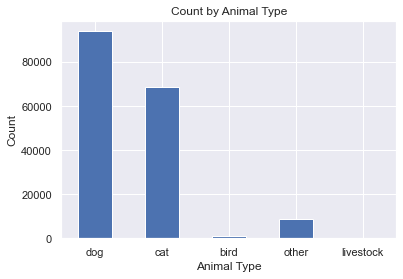

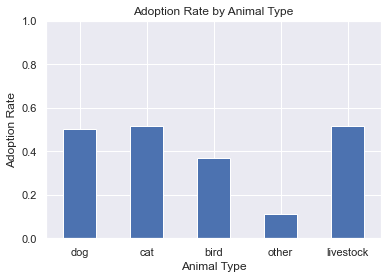

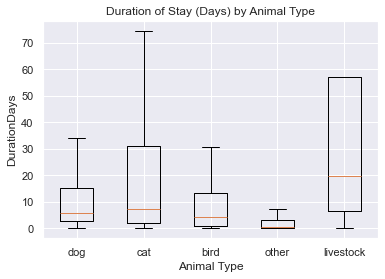

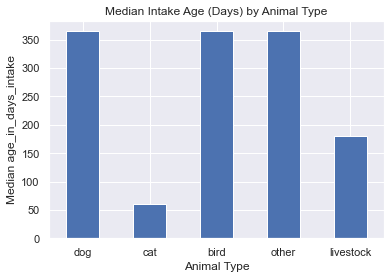


=== Summary by Animal Type ===
                  count  adoption_rate  median_duration_days  median_intake_age_days
Animal_Type_Norm                                                                    
dog               94025           0.50                  6.00                  365.00
cat               68917           0.51                  7.20                   60.00
bird                877           0.37                  4.17                  365.00
other              8948           0.11                  0.67                  365.00
livestock            33           0.52                 19.89                  180.00


In [49]:
df = final_df.copy()

# Normalize Animal_Type into the 5 buckets
def norm_type(x):
    if pd.isna(x): return "other"
    s = str(x).strip().lower()
    if "dog" in s:        return "dog"
    if "cat" in s:        return "cat"
    if "bird" in s:       return "bird"
    if "livestock" in s:  return "livestock"
    return "other"

df["Animal_Type_Norm"] = df["Animal_Type"].apply(norm_type)
type_order = ["dog","cat","bird","other","livestock"]
df = df[df["Animal_Type_Norm"].isin(type_order)].copy()

# Age at intake:
if "age_in_days_intake" not in df.columns:
    if "Intake_Age_Days" in df.columns:
        df["age_in_days_intake"] = df["Intake_Age_Days"]
    elif "Intake_Age_Years" in df.columns:
        df["age_in_days_intake"] = df["Intake_Age_Years"] * 365.25
    else:
        df["age_in_days_intake"] = np.nan

# dog/cat vs other split
df["Is_DogOrCat"] = df["Animal_Type_Norm"].isin(["dog","cat"]).astype(int)
print("Counts by Is_DogOrCat (1=dog/cat, 0=other types):")
print(df["Is_DogOrCat"].value_counts(dropna=False).to_string(), "\n")

# Count by Animal Type
counts = df["Animal_Type_Norm"].value_counts().reindex(type_order, fill_value=0)
plt.figure()
counts.plot(kind="bar")
plt.title("Count by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Adoption Rate by Animal Type
if "Outcome_Type" in df.columns:
    adoption_rate = (
        df.groupby("Animal_Type_Norm")["Outcome_Type"]
          .apply(lambda s: (s == "Adoption").mean())
          .reindex(type_order, fill_value=0.0)
    )
    plt.figure()
    adoption_rate.plot(kind="bar")
    plt.title("Adoption Rate by Animal Type")
    plt.xlabel("Animal Type")
    plt.ylabel("Adoption Rate")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.show()
else:
    adoption_rate = pd.Series(index=type_order, dtype=float)

# Duration of Stay by Animal Type
if "DurationDays" in df.columns:
    data_for_box = [df.loc[df["Animal_Type_Norm"] == t, "DurationDays"].dropna().values for t in type_order]
    plt.figure()
    plt.boxplot(data_for_box, labels=type_order, showfliers=False)
    plt.title("Duration of Stay (Days) by Animal Type")
    plt.xlabel("Animal Type")
    plt.ylabel("DurationDays")
    plt.show()
else:
    data_for_box = [np.array([]) for _ in type_order]

# Median Intake Age by Animal Type
age_median = df.groupby("Animal_Type_Norm")["age_in_days_intake"].median().reindex(type_order, fill_value=np.nan)
plt.figure()
age_median.plot(kind="bar")
plt.title("Median Intake Age (Days) by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Median age_in_days_intake")
plt.xticks(rotation=0)
plt.show()

# Compact summary table
summary_df = pd.DataFrame({
    "count": counts,
    "adoption_rate": adoption_rate,
    "median_duration_days": [np.nan if len(x)==0 else float(np.nanmedian(x)) for x in data_for_box],
    "median_intake_age_days": age_median
})
print("\n=== Summary by Animal Type ===")
print(summary_df.to_string())


<Figure size 432x288 with 0 Axes>

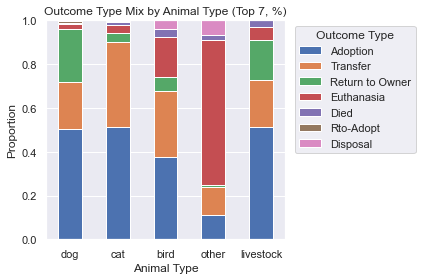

<Figure size 432x288 with 0 Axes>

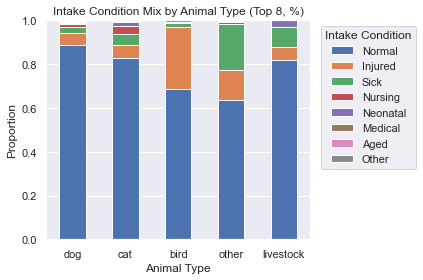

In [50]:

# Percent-stacked: Outcome Types by Animal Type
K_out = 7
top_outcomes = df["Outcome_Type"].fillna("unknown").value_counts().head(K_out).index

out_ctab = (
    df.assign(Outcome_Type=df["Outcome_Type"].fillna("unknown"))
      .groupby(["Animal_Type_Norm","Outcome_Type"]).size()
      .unstack(fill_value=0)
      .reindex(index=type_order, fill_value=0)
      .reindex(columns=top_outcomes, fill_value=0)
)

out_pct = out_ctab.div(out_ctab.sum(axis=1).replace(0, np.nan), axis=0)

plt.figure()
ax = out_pct.plot(kind="bar", stacked=True)
ax.set_title(f"Outcome Type Mix by Animal Type (Top {len(top_outcomes)}, %)")
ax.set_xlabel("Animal Type"); ax.set_ylabel("Proportion")
ax.set_xticks(range(len(type_order))); ax.set_xticklabels(type_order, rotation=0)
ax.legend(title="Outcome Type", bbox_to_anchor=(1.02,1), loc="upper left")
plt.ylim(0,1); plt.tight_layout(); plt.show()

# Percent-stacked: Intake Condition by Animal Type
K_in = 8
top_conditions = df["Intake_Condition"].fillna("unknown").value_counts().head(K_in).index

cond_ctab = (
    df.assign(Intake_Condition=df["Intake_Condition"].fillna("unknown"))
      .groupby(["Animal_Type_Norm","Intake_Condition"]).size()
      .unstack(fill_value=0)
      .reindex(index=type_order, fill_value=0)
      .reindex(columns=top_conditions, fill_value=0)
)

cond_pct = cond_ctab.div(cond_ctab.sum(axis=1).replace(0, np.nan), axis=0)

plt.figure()
ax = cond_pct.plot(kind="bar", stacked=True)
ax.set_title(f"Intake Condition Mix by Animal Type (Top {len(top_conditions)}, %)")
ax.set_xlabel("Animal Type"); ax.set_ylabel("Proportion")
ax.set_xticks(range(len(type_order))); ax.set_xticklabels(type_order, rotation=0)
ax.legend(title="Intake Condition", bbox_to_anchor=(1.02,1), loc="upper left")
plt.ylim(0,1); plt.tight_layout(); plt.show()



=== DurationDays (overall) summary ===
count    172800.00
min           0.00
p1            0.01
p5            0.07
p25           2.01
median        6.01
mean         21.05
p75          19.92
p95          84.81
p99         214.95
max        1912.94
std          48.41 

=== Overall outliers (IQR) ===
Q1=2.01, Q3=19.92, IQR=17.91 -> lower=-24.85, upper=46.78
Count: 21624

=== Overall outliers (MAD z-score) ===
median=6.01, MAD=5.17, |robust_z| > 3.5
Count: 30995

Top 20 longest stays (overall):
Animal ID Animal_Type_Norm     Intake_DateTime    Outcome_DateTime  DurationDays
  A642712              dog 2016-01-05 11:37:00 2021-04-01 10:08:00       1912.94
  A764237              cat 2017-12-26 12:08:00 2022-10-06 10:41:00       1744.94
  A722987              dog 2016-03-24 16:59:00 2020-05-24 16:30:00       1521.98
  A702369              cat 2015-05-12 16:45:00 2019-05-21 09:54:00       1469.71
  A707965              cat 2015-07-20 17:12:00 2019-05-28 09:45:00       1407.69
  A810081        

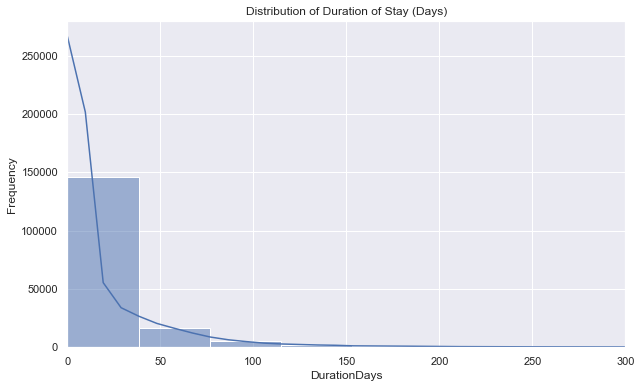

In [51]:
# Length of Stay (DurationDays) range + outlier detection


# Overall summary stats
dur = df["DurationDays"].dropna()
summary = pd.Series({
    "count": dur.size,
    "min": float(dur.min()),
    "p1": float(dur.quantile(0.01)),
    "p5": float(dur.quantile(0.05)),
    "p25": float(dur.quantile(0.25)),
    "median": float(dur.median()),
    "mean": float(dur.mean()),
    "p75": float(dur.quantile(0.75)),
    "p95": float(dur.quantile(0.95)),
    "p99": float(dur.quantile(0.99)),
    "max": float(dur.max()),
    "std": float(dur.std(ddof=1))
})
print("=== DurationDays (overall) summary ===")
print(summary.to_string(), "\n")

# Overall outliers (IQR + MAD)
Q1, Q3 = dur.quantile(0.25), dur.quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5*IQR
iqr_upper = Q3 + 1.5*IQR

med = dur.median()
mad = (dur - med).abs().median()
if mad == 0:
    robust_z = pd.Series(np.zeros_like(dur), index=dur.index)
else:
    robust_z = 0.6745 * (dur - med) / mad

outliers_iqr = df[(df["DurationDays"] < iqr_lower) | (df["DurationDays"] > iqr_upper)]
outliers_mad = df[robust_z.abs() > 3.5]

print(f"=== Overall outliers (IQR) ===")
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f} -> lower={iqr_lower:.2f}, upper={iqr_upper:.2f}")
print(f"Count: {len(outliers_iqr)}\n")

print(f"=== Overall outliers (MAD z-score) ===")
print(f"median={med:.2f}, MAD={mad:.2f}, |robust_z| > 3.5")
print(f"Count: {len(outliers_mad)}\n")

# Show a few extremes (highest stays) for inspection
print("Top 20 longest stays (overall):")
cols_show = ["Animal ID","Animal_Type_Norm","Intake_DateTime","Outcome_DateTime","DurationDays"]
print(df.sort_values("DurationDays", ascending=False)[cols_show].head(20).to_string(index=False), "\n")

# Per animal-type outliers (IQR)
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({"low": q1 - 1.5*iqr, "high": q3 + 1.5*iqr})

bounds_by_type = df.groupby("Animal_Type_Norm")["DurationDays"].apply(iqr_bounds).unstack()
print("=== IQR bounds by Animal_Type_Norm ===")
print(bounds_by_type.to_string(), "\n")

def flag_iqr(group):
    low, high = bounds_by_type.loc[group.name, "low"], bounds_by_type.loc[group.name, "high"]
    return (group["DurationDays"] < low) | (group["DurationDays"] > high)

df["is_outlier_iqr_by_type"] = df.groupby("Animal_Type_Norm", group_keys=False).apply(flag_iqr).astype(bool)

outlier_iqr_by_type_list = df[df["is_outlier_iqr_by_type"] ==True]['Animal ID'].to_list()

print("Outlier counts by Animal_Type_Norm (IQR):")
print(df.groupby("Animal_Type_Norm")["is_outlier_iqr_by_type"].sum().to_string(), "\n")

# Show top 10 outliers per type
print("Top 10 outliers per Animal_Type_Norm (IQR):")
for t, sub in df[df["is_outlier_iqr_by_type"]].groupby("Animal_Type_Norm"):
    print(f"\n-- {t} --")
    print(sub.sort_values("DurationDays", ascending=False)[cols_show].head(10).to_string(index=False))

# Visualize the distribution of DurationDays with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='DurationDays', bins=50, kde=True)
plt.title('Distribution of Duration of Stay (Days)')
plt.xlabel('DurationDays')
plt.ylabel('Frequency')
plt.xlim(0, 300) # Limit x-axis to better visualize the main distribution
plt.show()

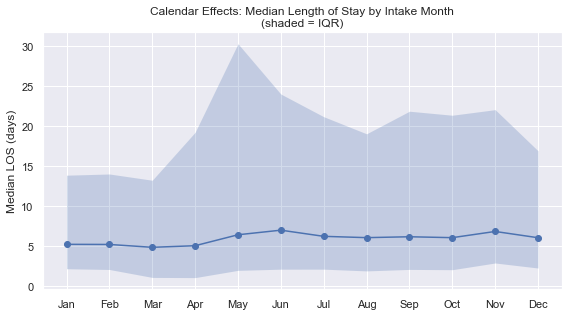

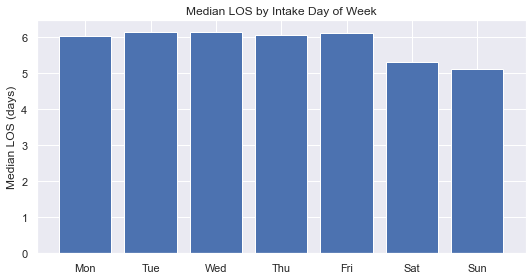

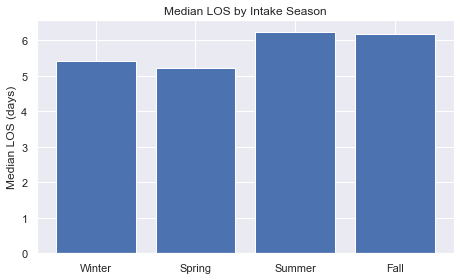

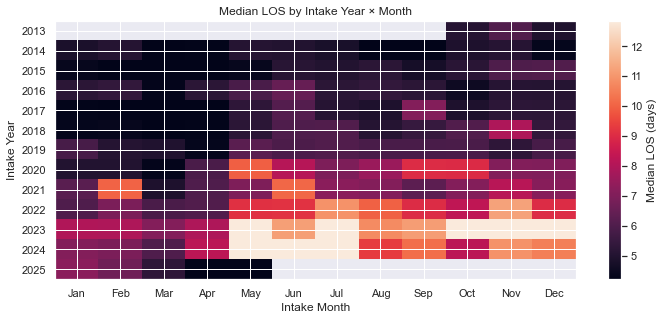

In [52]:
# === Calendar effects on Length of Stay (LOS) ===

try:
    base_df = final_df
except NameError:
    base_df = df

# Guard: required columns
_required = {"DurationDays", "Intake_Month", "Intake_DayOfWeek", "Intake_Season", "Intake_DateTime"}
missing = [c for c in _required if c not in base_df.columns]
if missing:
    raise ValueError(f"Missing expected columns for calendar EDA: {missing}")

cal = base_df.loc[:, ["DurationDays","Intake_Month","Intake_DayOfWeek","Intake_Season","Intake_DateTime"]].copy()
cal = cal.dropna(subset=["DurationDays"])

# 1) Monthly median LOS (with IQR band)

monthly = (
    cal.groupby("Intake_Month")["DurationDays"]
       .agg(median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
       .reindex(range(1, 13))
)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(8, 4.5))
plt.plot(range(1,13), monthly["median"].values, marker="o")
plt.fill_between(range(1,13), monthly["p25"].values, monthly["p75"].values, alpha=0.25, linewidth=0)
plt.xticks(range(1,13), month_labels, rotation=0)
plt.ylabel("Median LOS (days)")
plt.title("Calendar Effects: Median Length of Stay by Intake Month\n(shaded = IQR)")
plt.tight_layout()
plt.show()

# 2) Day-of-week median LOS (bar)

dow_order = list(range(7))
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow = cal.groupby("Intake_DayOfWeek")["DurationDays"].median().reindex(dow_order)

plt.figure(figsize=(7.5, 4))
plt.bar(dow_labels, dow.values)
plt.ylabel("Median LOS (days)")
plt.title("Median LOS by Intake Day of Week")
plt.tight_layout()
plt.show()

# 3) Season median LOS (bar)

season_order = ["Winter","Spring","Summer","Fall"]
season = cal.groupby("Intake_Season")["DurationDays"].median().reindex(season_order)

plt.figure(figsize=(6.5, 4))
plt.bar(season.index.astype(str), season.values)
plt.ylabel("Median LOS (days)")
plt.title("Median LOS by Intake Season")
plt.tight_layout()
plt.show()

# 4) Year × Month median LOS (heatmap)

cal["Intake_Year"] = cal["Intake_DateTime"].dt.year
ym = pd.pivot_table(
    cal, index="Intake_Year", columns="Intake_Month", values="DurationDays", aggfunc="median"
).sort_index()


vmin = np.nanquantile(ym.values, 0.05)
vmax = np.nanquantile(ym.values, 0.95)

plt.figure(figsize=(10, max(4.5, 0.35 * ym.shape[0])))
im = plt.imshow(ym, aspect="auto", vmin=vmin, vmax=vmax)
plt.colorbar(im, label="Median LOS (days)")
plt.yticks(ticks=range(ym.shape[0]), labels=ym.index.astype(int))
plt.xticks(ticks=range(12), labels=month_labels, rotation=0)
plt.xlabel("Intake Month")
plt.ylabel("Intake Year")
plt.title("Median LOS by Intake Year × Month")
plt.tight_layout()
plt.show()


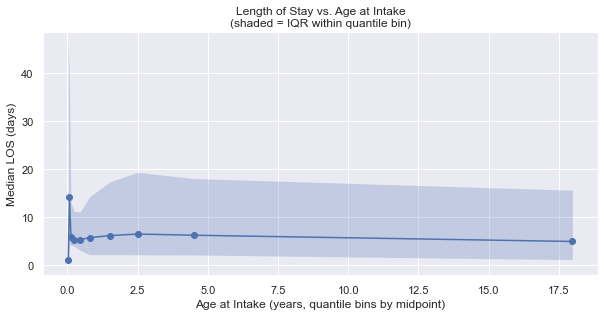

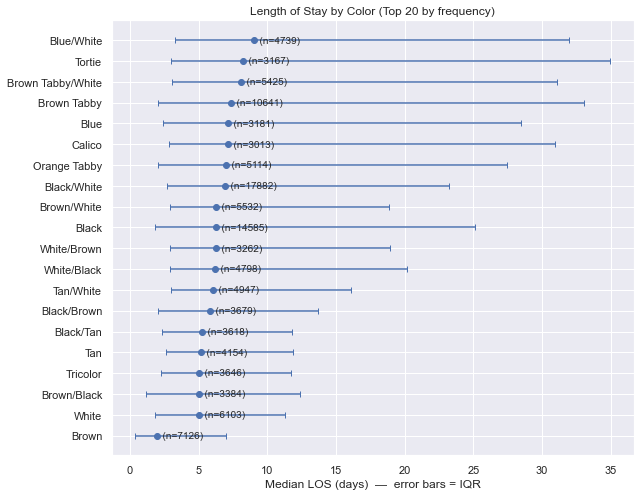

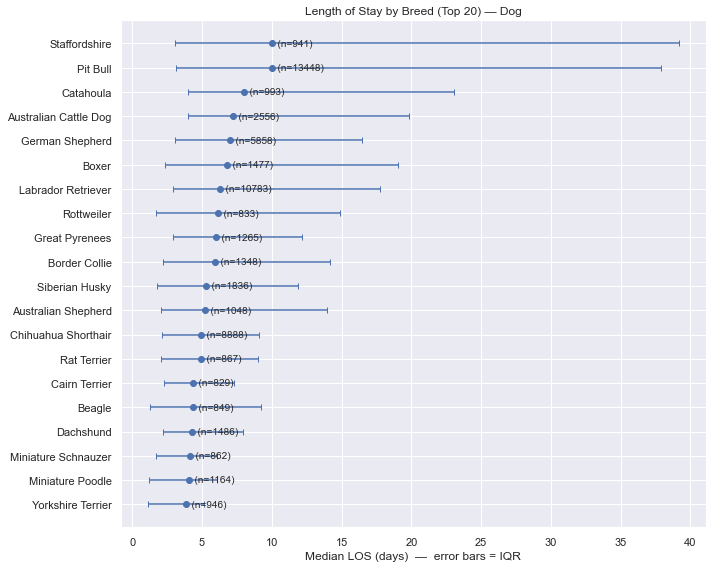

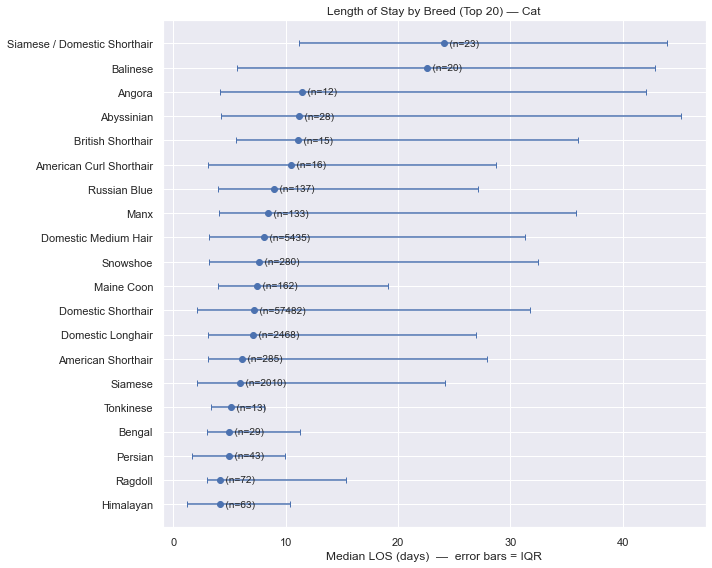

In [53]:
# === LOS vs Age-at-Intake, Color, and Breed ===

try:
    base_df = final_df
except NameError:
    base_df = df

req = {"DurationDays", "age_in_days_intake", "Color", "Breed"}
missing = [c for c in req if c not in base_df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

work = base_df.loc[:, ["DurationDays", "age_in_days_intake", "Color", "Breed", "Animal_Type"] \
                   if "Animal_Type" in base_df.columns else ["DurationDays", "age_in_days_intake", "Color", "Breed"]].copy()
work = work.dropna(subset=["DurationDays", "age_in_days_intake"])
work = work[(work["DurationDays"] >= 0) & (work["age_in_days_intake"] >= 0)]


# 1) LOS vs. Age at Intake (quantile-binned line with IQR band)

age = work.loc[:, ["DurationDays", "age_in_days_intake"]].copy()
age["age_years"] = age["age_in_days_intake"] / 365.25

# Build quantile bins (12 bins -> monthly-ish resolution without being noisy)
qgrid = np.linspace(0, 1, 13)
bins = np.unique(np.quantile(age["age_years"], qgrid))
# In case of duplicate quantiles (heavy mass at 0 etc.), drop duplicates via np.unique above
age["age_bin"] = pd.cut(age["age_years"], bins=bins, include_lowest=True, duplicates="drop")

age_summary = (
    age.groupby("age_bin")["DurationDays"]
       .agg(median="median",
            p25=lambda s: s.quantile(0.25),
            p75=lambda s: s.quantile(0.75),
            n="size")
       .reset_index()
)
# X positions = bin midpoints for a smooth line
def _midpoint(interval) -> float:
    return (interval.left + interval.right) / 2 if pd.api.types.is_interval(interval) else np.nan

age_summary["bin_mid"] = age_summary["age_bin"].apply(_midpoint)

plt.figure(figsize=(8.5, 4.5))
plt.plot(age_summary["bin_mid"], age_summary["median"], marker="o")
plt.fill_between(age_summary["bin_mid"], age_summary["p25"], age_summary["p75"], alpha=0.25, linewidth=0)
plt.xlabel("Age at Intake (years, quantile bins by midpoint)")
plt.ylabel("Median LOS (days)")
plt.title("Length of Stay vs. Age at Intake\n(shaded = IQR within quantile bin)")
plt.tight_layout()
plt.show()


# 2) LOS vs. Color (top-K; horizontal bars sorted by median)

K = 20  # adjust if you want more/less categories
top_colors = (work["Color"].fillna("unknown").value_counts().head(K).index)

color_df = (
    work[work["Color"].isin(top_colors)]
      .groupby("Color")["DurationDays"]
      .agg(median="median",
           p25=lambda s: s.quantile(0.25),
           p75=lambda s: s.quantile(0.75),
           n="size")
      .sort_values("median", ascending=False)
      .reset_index()
)

# Error bars: show IQR extent around the median (no box plots)
ypos = np.arange(len(color_df))
ylabels = color_df["Color"].astype(str)

err_low  = color_df["median"] - color_df["p25"]
err_high = color_df["p75"] - color_df["median"]
yerr = [err_low.values, err_high.values]

plt.figure(figsize=(9, max(5, 0.35 * len(color_df))))
plt.errorbar(color_df["median"], ypos, xerr=yerr, fmt="o", capsize=3)
plt.yticks(ypos, ylabels)
plt.gca().invert_yaxis()
plt.xlabel("Median LOS (days)  —  error bars = IQR")
plt.title(f"Length of Stay by Color (Top {K} by frequency)")
# optional counts on the right
for i, n in enumerate(color_df["n"].values):
    plt.text(color_df["median"].iloc[i], i, f"  (n={int(n)})", va="center", ha="left")
plt.tight_layout()
plt.show()

# 3) LOS vs. Breed (top-K; separate figures for Dogs and Cats if available)

def plot_breed_for_species(df, species_label=None, K=20):
    tmp = df.copy()
    if species_label is not None and "Animal_Type" in tmp.columns:
        tmp = tmp[tmp["Animal_Type"].str.lower() == species_label.lower()]
        subtitle = f"{species_label.title()}"
    else:
        subtitle = "All Species"

    # Defensive cleaning
    tmp["Breed"] = tmp["Breed"].fillna("unknown").astype(str).str.strip()

    top_breeds = tmp["Breed"].value_counts().head(K).index
    summ = (
        tmp[tmp["Breed"].isin(top_breeds)]
           .groupby("Breed")["DurationDays"]
           .agg(median="median",
                p25=lambda s: s.quantile(0.25),
                p75=lambda s: s.quantile(0.75),
                n="size")
           .sort_values("median", ascending=False)
           .reset_index()
    )

    ypos = np.arange(len(summ))
    err_low  = summ["median"] - summ["p25"]
    err_high = summ["p75"] - summ["median"]
    yerr = [err_low.values, err_high.values]

    plt.figure(figsize=(10, max(5, 0.4 * len(summ))))
    plt.errorbar(summ["median"], ypos, xerr=yerr, fmt="o", capsize=3)
    plt.yticks(ypos, summ["Breed"].astype(str))
    plt.gca().invert_yaxis()
    plt.xlabel("Median LOS (days)  —  error bars = IQR")
    plt.title(f"Length of Stay by Breed (Top {K}) — {subtitle}")
    for i, n in enumerate(summ["n"].values):
        plt.text(summ["median"].iloc[i], i, f"  (n={int(n)})", va="center", ha="left")
    plt.tight_layout()
    plt.show()

# Render breed plots
if "Animal_Type" in work.columns:
    plot_breed_for_species(work, species_label="dog", K=20)
    plot_breed_for_species(work, species_label="cat", K=20)
else:
    plot_breed_for_species(work, species_label=None, K=20)


In [54]:
# has_name: 1 if a real name appears; 0 if unknown/blank
final_df['has_name'] = (
    final_df['Name'].astype(str).str.strip().str.lower()
      .replace({'': np.nan, 'unknown': np.nan, 'unnamed': np.nan, 'no name': np.nan})
      .notna()
).astype('Int64')
final_df = final_df.drop(columns=['Name'], errors='ignore')

In [55]:
# --- Raw unique colors (just to see what's in there) ---
raw_unique_colors = (final_df.get('Color')
                     .dropna()
                     .astype(str)
                     .str.strip()
                     .unique()
                    )
print(f"Raw unique colors (count={len(raw_unique_colors)}):")
print(sorted(raw_unique_colors))

Raw unique colors (count=660):
['Agouti', 'Agouti/Brown Tabby', 'Agouti/Cream', 'Agouti/Gold', 'Agouti/Gray', 'Agouti/White', 'Apricot', 'Apricot/Brown', 'Apricot/Tricolor', 'Apricot/White', 'Black', 'Black Brindle', 'Black Brindle/Black', 'Black Brindle/Blue', 'Black Brindle/Blue Tick', 'Black Brindle/Brown', 'Black Brindle/Brown Brindle', 'Black Brindle/Tan', 'Black Brindle/White', 'Black Brindle/Yellow', 'Black Smoke', 'Black Smoke/Black', 'Black Smoke/Black Tabby', 'Black Smoke/Black Tiger', 'Black Smoke/Blue Tick', 'Black Smoke/Brown', 'Black Smoke/Brown Tabby', 'Black Smoke/Chocolate', 'Black Smoke/Gray', 'Black Smoke/White', 'Black Tabby', 'Black Tabby/Black', 'Black Tabby/Black Smoke', 'Black Tabby/Brown', 'Black Tabby/Gray', 'Black Tabby/Gray Tabby', 'Black Tabby/Orange', 'Black Tabby/White', 'Black Tiger', 'Black Tiger/White', 'Black/Black', 'Black/Black Brindle', 'Black/Black Smoke', 'Black/Black Tabby', 'Black/Blue', 'Black/Blue Merle', 'Black/Blue Tick', 'Black/Brown', 'Bl

,Breed,Count
0,Domestic Shorthair Mix,33656
1,Domestic Shorthair,24186
2,Pit Bull Mix,10089
3,Labrador Retriever Mix,8806
4,Chihuahua Shorthair Mix,6888
...,...,...
95,Cardigan Welsh Corgi Mix,170
96,Pomeranian Mix,166
97,Chinese Sharpei Mix,164
98,Cocker Spaniel Mix,161


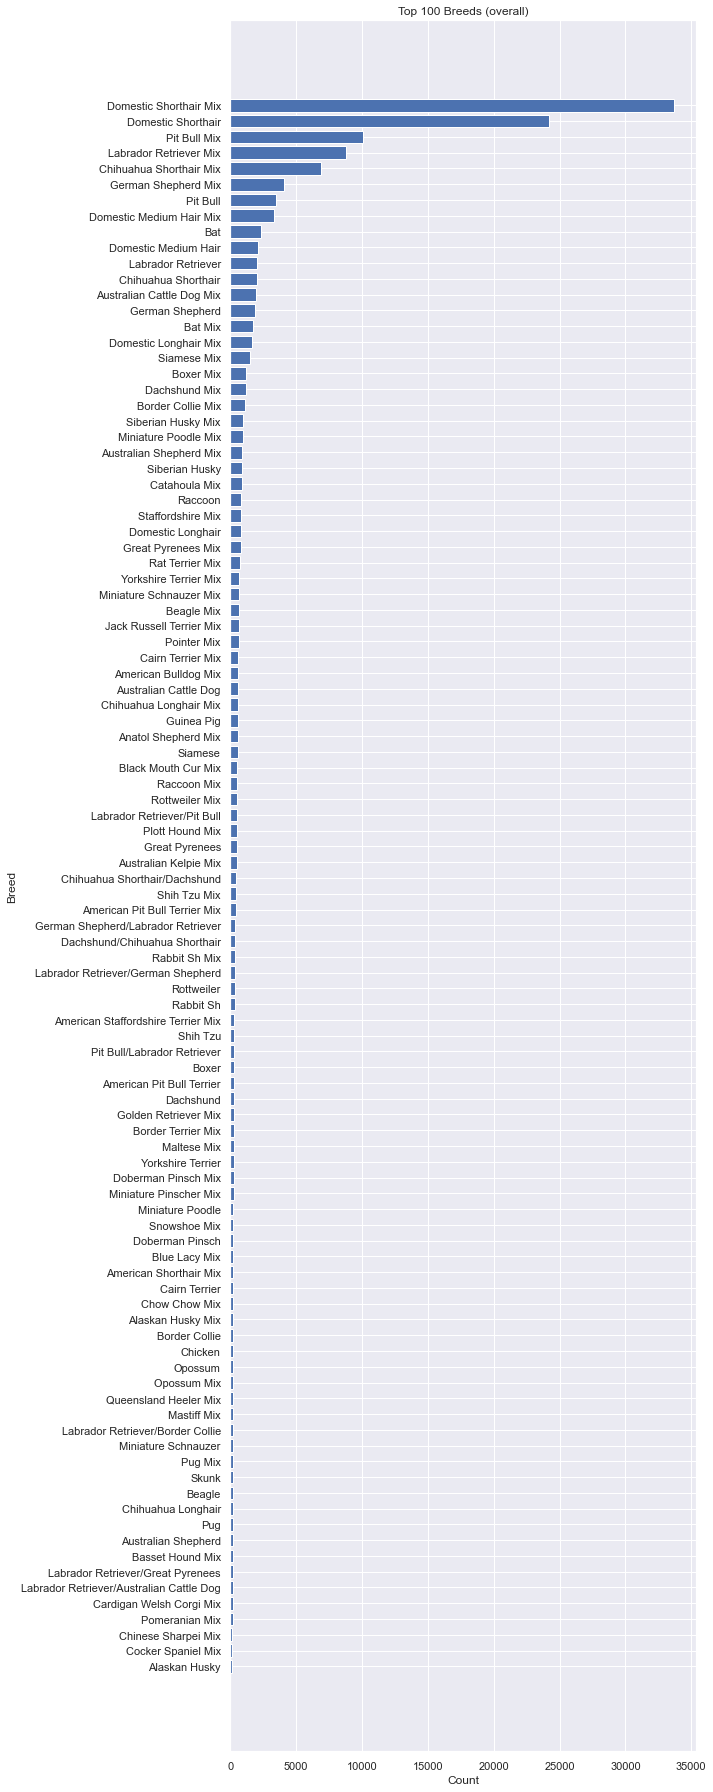

In [56]:
K = 100

breeds_series = (
    intakes_df['Breed']
    .dropna()
    .astype(str)
    .str.strip()
)

top_overall = breeds_series.value_counts().head(K).reset_index()
top_overall.columns = ['Breed', 'Count']

# quick table peek
display(top_overall)

# horizontal bar chart
plt.figure(figsize=(10, max(4, K*0.25)))
plt.barh(top_overall['Breed'][::-1], top_overall['Count'][::-1])
plt.xlabel('Count')
plt.ylabel('Breed')
plt.title(f'Top {K} Breeds (overall)')
plt.tight_layout()
plt.show()


,Breed,Count
0,Domestic Shorthair,57482
1,Pit Bull,13448
2,Labrador Retriever,10783
3,Chihuahua Shorthair,8888
4,German Shepherd,5858
5,Domestic Medium Hair,5435
6,Bat,4109
7,Australian Cattle Dog,2556
8,Domestic Longhair,2468
9,Siamese,2010


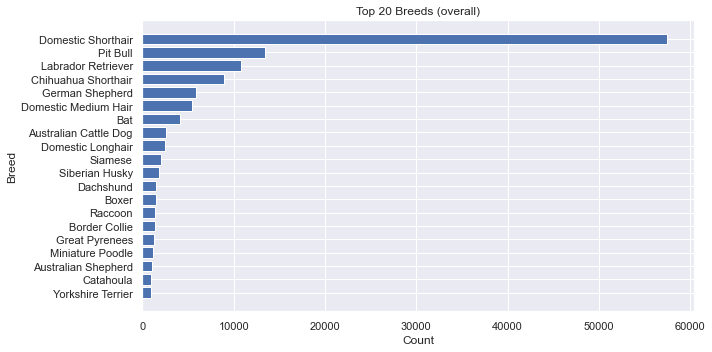

In [57]:
K = 20

breeds_series = (
    final_df['Breed']
    .dropna()
    .astype(str)
    .str.strip()
)

top_overall = breeds_series.value_counts().head(K).reset_index()
top_overall.columns = ['Breed', 'Count']

# quick table peek
display(top_overall)

# horizontal bar chart
plt.figure(figsize=(10, max(4, K*0.25)))
plt.barh(top_overall['Breed'][::-1], top_overall['Count'][::-1])
plt.xlabel('Count')
plt.ylabel('Breed')
plt.title(f'Top {K} Breeds (overall)')
plt.tight_layout()
plt.show()



Top 80 breeds — Dog


,Breed,Count
0,Pit Bull,13448
1,Labrador Retriever,10783
2,Chihuahua Shorthair,8888
3,German Shepherd,5858
4,Australian Cattle Dog,2556
...,...,...
75,Wire Hair Fox Terrier,133
76,Redbone Hound,133
77,Siberian Husky / German Shepherd,129
78,Pit Bull / Boxer,124


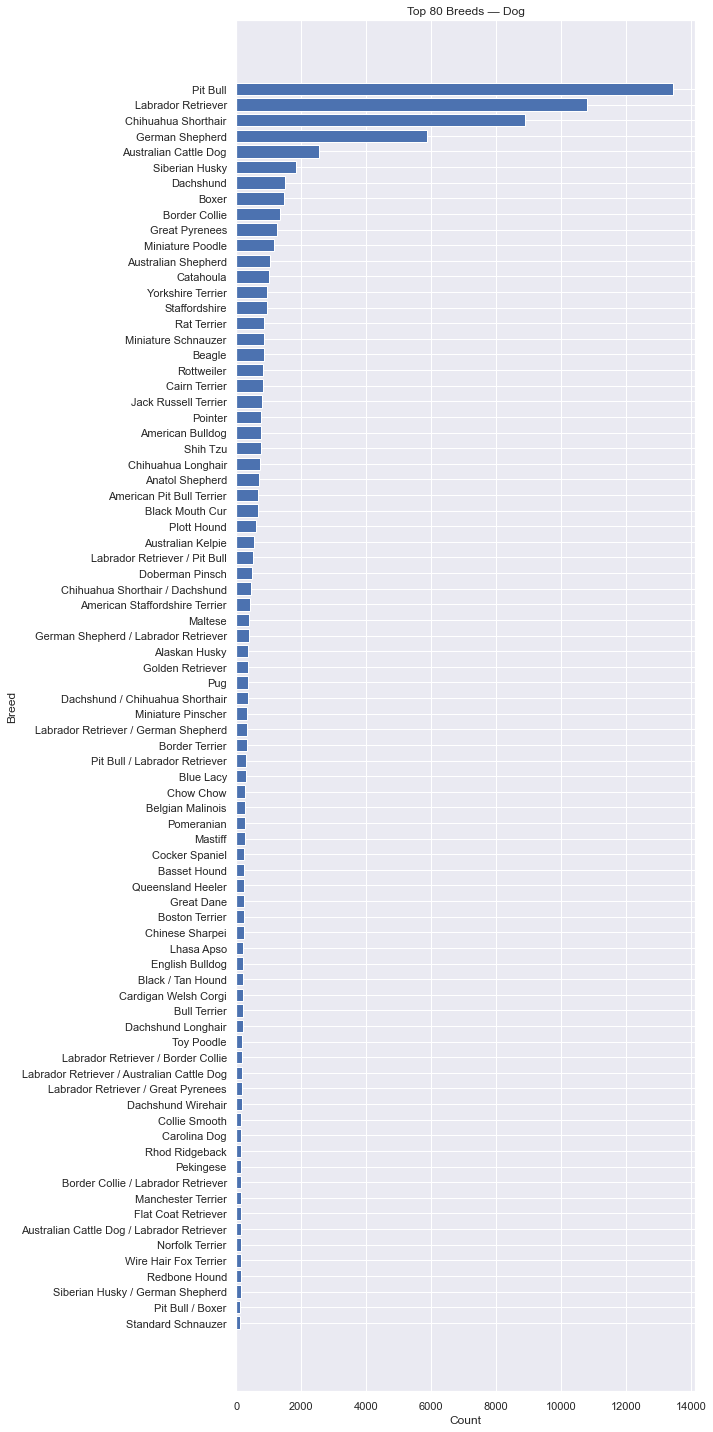


Top 80 breeds — Cat


,Breed,Count
0,Domestic Shorthair,57482
1,Domestic Medium Hair,5435
2,Domestic Longhair,2468
3,Siamese,2010
4,American Shorthair,285
...,...,...
75,Domestic Shorthair / Maine Coon,1
76,Ocicat,1
77,American Wirehair,1
78,Manx / Siamese,1


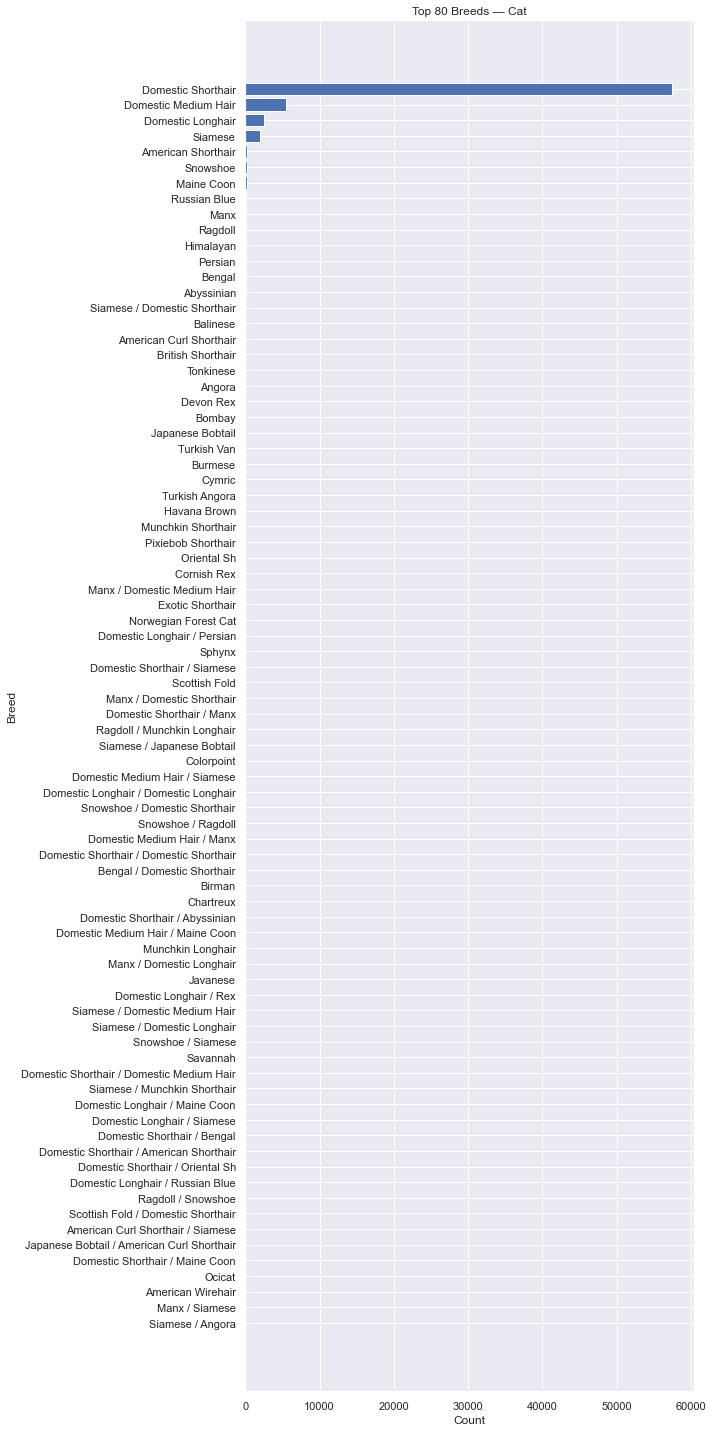

In [58]:
# ---- params ----
K = 80  # top-K per species
species_col = "Animal_Type"
breed_col   = "Breed"

# safety checks
assert species_col in final_df.columns, f"Missing column: {species_col}"
assert breed_col   in final_df.columns, f"Missing column: {breed_col}"

# prep (read-only)
df = final_df.dropna(subset=[species_col, breed_col]).copy()
df["__breed_tmp__"] = df[breed_col].astype(str).str.strip()
df["__species_tmp__"] = df[species_col].astype(str).str.strip()

def plot_top_k_for_species(df, species_value, K=20):
    sub = df[df["__species_tmp__"] == species_value]
    if sub.empty:
        print(f"No rows for species '{species_value}'.")
        return

    top = sub["__breed_tmp__"].value_counts().head(K).reset_index()
    top.columns = ["Breed", "Count"]

    # table preview
    print(f"\nTop {K} breeds — {species_value}")
    display(top)

    # horizontal bar chart
    plt.figure(figsize=(10, max(4, len(top)*0.25)))
    plt.barh(top["Breed"][::-1], top["Count"][::-1])
    plt.xlabel("Count")
    plt.ylabel("Breed")
    plt.title(f"Top {K} Breeds — {species_value}")
    plt.tight_layout()
    plt.show()

# plots
plot_top_k_for_species(df, "Dog", K=K)
plot_top_k_for_species(df, "Cat", K=K)


,Animal_Type,Episodes,Percent,CumPercent
0,Dog,94025,0.54,0.54
1,Cat,68917,0.40,0.94
2,Other,8948,0.05,0.99
3,Bird,877,0.01,1.00
4,Livestock,33,0.00,1.00


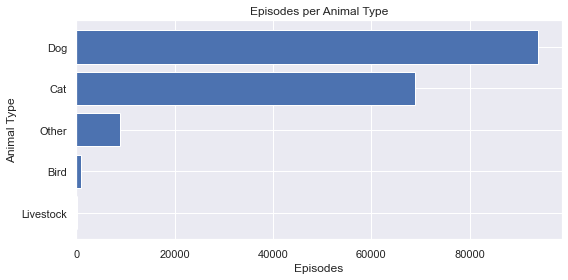

In [59]:
species_col = "Animal_Type"
assert species_col in final_df.columns, f"Missing column: {species_col}"

# Counts, percent, cumulative percent
counts = (final_df[species_col]
          .fillna("Unknown")
          .value_counts()
          .rename_axis("Animal_Type")
          .reset_index(name="Episodes"))
counts["Percent"] = counts["Episodes"] / len(final_df)
counts["CumPercent"] = counts["Percent"].cumsum()

display(counts)

# Horizontal bar chart
plt.figure(figsize=(8, max(4, 0.35*len(counts))))
plt.barh(counts["Animal_Type"][::-1], counts["Episodes"][::-1])
plt.xlabel("Episodes")
plt.ylabel("Animal Type")
plt.title("Episodes per Animal Type")
plt.tight_layout()
plt.show()


In [60]:
model_df = final_df.copy()

# OUTCOME-derived columns to drop

OUTCOME_COLS = [
    # canonical outcome fields
    "Outcome_DateTime",
    "Outcome_Type",
    "Outcome_Subtype",
    "Outcome_SpayNeuter",

    # calendar derived from outcome
    "Outcome_Month",
    "Outcome_DayOfWeek",
    "Outcome_Season",
    "Outcome_Season_Code",

    # age derived from outcome
    "age_in_days_outcome",
    "age_group_outcome"

]

to_drop = [c for c in OUTCOME_COLS if c in model_df.columns]
model_df = model_df.drop(columns=to_drop).copy()

print("Dropped outcome-derived columns:")
print(sorted(to_drop))


Dropped outcome-derived columns:
['Outcome_DateTime', 'Outcome_DayOfWeek', 'Outcome_Month', 'Outcome_Season', 'Outcome_Season_Code', 'Outcome_SpayNeuter', 'Outcome_Subtype', 'Outcome_Type', 'age_group_outcome', 'age_in_days_outcome']


In [61]:
# keep only Dogs & Cats for modeling

model_df = model_df[model_df["Animal_Type"].isin(["Dog", "Cat"])].copy()

# Split into Dog and Cat DataFrames

dog_df = model_df[model_df["Animal_Type"] == "Dog"].copy()
cat_df = model_df[model_df["Animal_Type"] == "Cat"].copy()

print(f"model_df shape (Dog+Cat): {model_df.shape}")
print(f"dog_df shape: {dog_df.shape}")
print(f"cat_df shape: {cat_df.shape}")


model_df shape (Dog+Cat): (162942, 18)
dog_df shape: (94025, 18)
cat_df shape: (68917, 18)


In [62]:
# quick sanity peek of remaining columns

print("\nRemaining columns (sample):")
print(sorted(model_df.columns.tolist()))


Remaining columns (sample):
['Animal ID', 'Animal_Type', 'Breed', 'Breed_Is_Mix', 'Color', 'DurationDays', 'Gender', 'Intake_Condition', 'Intake_DateTime', 'Intake_DayOfWeek', 'Intake_Month', 'Intake_Season', 'Intake_Season_Code', 'Intake_SpayNeuter', 'Intake_Type', 'age_group_intake', 'age_in_days_intake', 'has_name']


In [63]:
# Unique values per column in cat_df and dog_df


unique_counts = cat_df.nunique(dropna=True)
summary = (pd.DataFrame({
    "unique_count_excl_NA": unique_counts,
    "dtype": cat_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())

unique_counts = dog_df.nunique(dropna=True)
summary = (pd.DataFrame({
    "unique_count_excl_NA": unique_counts,
    "dtype": dog_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())

                    unique_count_excl_NA           dtype
Animal ID                          65861          object
Intake_DateTime                    39373  datetime64[ns]
DurationDays                       34190         float64
Color                                327          object
Breed                                 83          object
age_in_days_intake                    44           int64
Intake_Condition                      18          object
Intake_Month                          12           int32
Intake_DayOfWeek                       7           int32
Intake_Type                            5          object
age_group_intake                       4          object
Intake_Season                          4          object
Intake_Season_Code                     4           int64
Intake_SpayNeuter                      3          object
Gender                                 3          object
Breed_Is_Mix                           2           Int64
has_name                       

In [64]:

# Config: base colors & patterns

BASE_COLORS = [
    "black","white","brown","tan","gray","blue","red","fawn",
    "cream","yellow","gold","buff","orange","chocolate","liver","silver",
    "apricot", "lilac"
]
COLOR_ALIASES = {
    "grey": "gray",
    "golden": "gold",
}

PATTERNS = {
    # pattern : list of trigger phrases (lowercase)
    "Tabby":    ["tabby", "tiger"],
    "Brindle":  ["brindle"],
    "Merle":    ["merle"],
    "Tortie":   ["tortie"],
    "Torbie":   ["torbie"],
    "Calico":   ["calico"],
    # Expand Point to also match common tokens even if "point" is omitted
    "Point":    ["seal point", "lynx point", "flame point", "lilac point", "blue point", "point",
                 "lynx", "seal", "flame", "lilac"],
    "Tick":     ["tick"],      # catches 'red tick', 'blue tick', 'ticked'
    "Smoke":    ["smoke"],
    "Sable":    ["sable"],
    "Tricolor": ["tricolor", "tri color", "tri-color"],
}

def _get_color_text(df):
    """Pick Intake_Color if present else Color; returns a normalized lowercase Series."""
    if "Intake_Color" in df.columns:
        s = df["Intake_Color"].fillna("")
    elif "Color" in df.columns:
        s = df["Color"].fillna("")
    else:
        return pd.Series([""] * len(df), index=df.index, dtype=object)

    s = s.astype(str).str.lower()
    # normalize aliases (e.g., grey -> gray, golden -> gold)
    for src, dst in COLOR_ALIASES.items():
        s = s.str.replace(rf"\b{src}\b", dst, regex=True)
    return s

def add_color_pattern_booleans(df):
    """Adds one boolean column per base color and per pattern. Leaves all existing columns untouched."""
    df = df.copy()

    if not (("Intake_Color" in df.columns) or ("Color" in df.columns)):
        return df  # nothing to do

    s = _get_color_text(df)

    # Color booleans
    for col in BASE_COLORS:
        df[f"Color_{col.title()}"] = s.str.contains(rf"\b{col}\b", regex=True).astype("Int64")

    # Pattern booleans =
    for pat, triggers in PATTERNS.items():
        escaped = [re.escape(t) for t in triggers]
        regex = "|".join(escaped)
        df[f"Pattern_{pat}"] = s.str.contains(regex, regex=True).astype("Int64")

    return df

# Apply to split frames
cat_df = add_color_pattern_booleans(cat_df)
dog_df = add_color_pattern_booleans(dog_df)

# quick sanity check
def coverage_report(df, label):
    color_cols = [c for c in df.columns if c.startswith("Color_")]
    pattern_cols = [c for c in df.columns if c.startswith("Pattern_")]
    if len(df) == 0:
        print(f"{label}: empty")
        return
    any_color = (df[color_cols].fillna(0).astype(int).sum(axis=1) > 0).mean() if color_cols else 0
    any_pattern = (df[pattern_cols].fillna(0).astype(int).sum(axis=1) > 0).mean() if pattern_cols else 0
    print(f"{label}: matched any base color in {any_color:.0%} of rows; any pattern in {any_pattern:.0%} of rows")
    if color_cols:
        print(f"{label}: top colors\n", df[color_cols].mean().sort_values(ascending=False).head(8))
    if pattern_cols:
        print(f"{label}: top patterns\n", df[pattern_cols].mean().sort_values(ascending=False).head(8))

coverage_report(cat_df, "Cats")
coverage_report(dog_df, "Dogs")


Cats: matched any base color in 85% of rows; any pattern in 66% of rows
Cats: top colors
 Color_White    0.35
Color_Black    0.25
Color_Brown    0.25
Color_Blue     0.13
Color_Orange   0.12
Color_Cream    0.03
Color_Gray     0.02
Color_Silver   0.00
dtype: Float64
Cats: top patterns
 Pattern_Tabby      0.47
Pattern_Tortie     0.05
Pattern_Calico     0.05
Pattern_Point      0.04
Pattern_Torbie     0.04
Pattern_Smoke      0.00
Pattern_Tricolor   0.00
Pattern_Brindle    0.00
dtype: Float64
Dogs: matched any base color in 96% of rows; any pattern in 16% of rows
Dogs: top colors
 Color_White       0.54
Color_Black       0.36
Color_Brown       0.28
Color_Tan         0.20
Color_Blue        0.06
Color_Red         0.05
Color_Chocolate   0.03
Color_Gray        0.02
dtype: Float64
Dogs: top patterns
 Pattern_Brindle    0.07
Pattern_Tricolor   0.05
Pattern_Merle      0.02
Pattern_Sable      0.01
Pattern_Tick       0.01
Pattern_Tabby      0.00
Pattern_Smoke      0.00
Pattern_Calico     0.00
dtype: 

In [65]:
import re

def unmatched_tokens_report(df, n=20):
    s = (df["Intake_Color"] if "Intake_Color" in df.columns else df["Color"]).fillna("").astype(str).str.lower()
    for src, dst in COLOR_ALIASES.items():
        s = s.str.replace(rf"\b{src}\b", dst, regex=True)

    # tokens in any row with no color match yet
    color_cols = [c for c in df.columns if c.startswith("Color_")]
    no_match = df[color_cols].fillna(0).sum(axis=1).eq(0)
    tokens = s[no_match].str.replace("/", " ", regex=False).str.findall(r"[a-z]+")
    vc = pd.Series([t for row in tokens for t in row]).value_counts()

    # hide things we already intentionally handle as patterns
    pattern_triggers = set(t for lst in PATTERNS.values() for t in lst)
    known = set(BASE_COLORS) | pattern_triggers | set(COLOR_ALIASES.keys())
    print(vc[~vc.index.isin(known)].head(n))

print("Cats unmatched tokens:")
unmatched_tokens_report(cat_df)
print("\nDogs unmatched tokens:")
unmatched_tokens_report(dog_df)


Cats unmatched tokens:
agouti    21
pink       2
ruddy      1
green      1
Name: count, dtype: int64

Dogs unmatched tokens:
agouti    4
Name: count, dtype: int64


In [66]:

#  helpers
def topk_by_coverage(series: pd.Series, *, target: float = 0.80, min_k: int = 0, max_k: int | None = None) -> list:
    """
    Return the Top-K categories from `series` such that cumulative frequency >= target,
    but at least `min_k`. If max_k is set, cap K at max_k.
    """
    vc = series.value_counts(dropna=True)
    if vc.empty:
        return []
    cum = (vc / vc.sum()).cumsum().values
    k_target = int(np.searchsorted(cum, target, side="left") + 1)
    k = max(min_k, k_target)
    if max_k is not None:
        k = min(k, max_k)
    k = min(k, len(vc))  # don't exceed unique count
    return vc.index[:k].tolist()

def make_topk_grouped(series: pd.Series, top_values: list, other_label: str = "Other") -> pd.Series:
    """Keep Top-K labels, map the rest to 'Other'. Returns an ordered categorical."""
    s = series.copy()
    grouped = s.where(s.isin(top_values), other_label)
    cats = list(top_values) + [other_label]
    return grouped.astype(pd.CategoricalDtype(categories=cats, ordered=False))

def report_topk(series: pd.Series, top_values: list, label: str):
    coverage = series.isin(top_values).mean() if len(series) else 0.0
    print(f"{label}: K={len(top_values)} | coverage={coverage:.0%} | first 10: {top_values[:10]}")

#  species-specific settings
TARGET_CATS = 0.85
TARGET_DOGS = 0.82
MIN_K_CATS  = 10
MIN_K_DOGS  = 60
MAXK_CATS   = 30
MAXK_DOGS   = 130

# safety checks
assert "Breed" in cat_df.columns and "Breed" in dog_df.columns, "Both frames must have a 'Breed' column."

# choose Top-K per species
cat_top = topk_by_coverage(cat_df["Breed"], target=TARGET_CATS, min_k=MIN_K_CATS, max_k=MAXK_CATS)
dog_top = topk_by_coverage(dog_df["Breed"], target=TARGET_DOGS, min_k=MIN_K_DOGS, max_k=MAXK_DOGS)

report_topk(cat_df["Breed"], cat_top, "Cats")
report_topk(dog_df["Breed"], dog_top, "Dogs")

# create grouped categorical columns (original Breed untouched)
cat_df["Breed_TopK"] = make_topk_grouped(cat_df["Breed"], cat_top, other_label="Other")
dog_df["Breed_TopK"] = make_topk_grouped(dog_df["Breed"], dog_top, other_label="Other")

# quick sanity peek
display(cat_df[["Breed","Breed_TopK"]].head(10))
display(dog_df[["Breed","Breed_TopK"]].head(10))



Cats: K=10 | coverage=99% | first 10: ['Domestic Shorthair', 'Domestic Medium Hair', 'Domestic Longhair', 'Siamese', 'American Shorthair', 'Snowshoe', 'Maine Coon', 'Russian Blue', 'Manx', 'Ragdoll']
Dogs: K=78 | coverage=82% | first 10: ['Pit Bull', 'Labrador Retriever', 'Chihuahua Shorthair', 'German Shepherd', 'Australian Cattle Dog', 'Siberian Husky', 'Dachshund', 'Boxer', 'Border Collie', 'Great Pyrenees']


,Breed,Breed_TopK
11,Domestic Longhair,Domestic Longhair
12,American Shorthair,American Shorthair
17,Domestic Shorthair,Domestic Shorthair
21,Snowshoe,Snowshoe
28,Domestic Shorthair,Domestic Shorthair
31,Domestic Shorthair,Domestic Shorthair
37,Domestic Shorthair,Domestic Shorthair
42,Domestic Shorthair,Domestic Shorthair
43,Domestic Longhair,Domestic Longhair
46,Domestic Shorthair,Domestic Shorthair


,Breed,Breed_TopK
0,Spinone Italiano,Other
1,Spinone Italiano,Other
2,Spinone Italiano,Other
3,Dachshund,Dachshund
4,Shetland Sheepdog,Other
5,Labrador Retriever / Pit Bull,Labrador Retriever / Pit Bull
6,Miniature Schnauzer,Miniature Schnauzer
7,Lhasa Apso,Lhasa Apso
9,Shetland Sheepdog,Other
10,Shetland Sheepdog,Other


In [67]:
# Unique values per column in cat_df and dog_df


unique_counts = cat_df.nunique(dropna=True)
summary = (pd.DataFrame({
    "unique_count_excl_NA": unique_counts,
    "dtype": cat_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())

unique_counts = dog_df.nunique(dropna=True)
summary = (pd.DataFrame({
    "unique_count_excl_NA": unique_counts,
    "dtype": dog_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())

                    unique_count_excl_NA           dtype
Animal ID                          65861          object
Intake_DateTime                    39373  datetime64[ns]
DurationDays                       34190         float64
Color                                327          object
Breed                                 83          object
age_in_days_intake                    44           int64
Intake_Condition                      18          object
Intake_Month                          12           int32
Breed_TopK                            11        category
Intake_DayOfWeek                       7           int32
Intake_Type                            5          object
age_group_intake                       4          object
Intake_Season                          4          object
Intake_Season_Code                     4           int64
Intake_SpayNeuter                      3          object
Gender                                 3          object
Breed_Is_Mix                   

In [68]:
def drop_constant_cols(df: pd.DataFrame, verbose=True):
    nunq = df.nunique(dropna=True)
    const_cols = nunq[nunq <= 1].index.tolist()
    if const_cols and verbose:
        print(f"Dropping constant cols: {const_cols}")
    return df.drop(columns=const_cols, errors="ignore")

dog_df = drop_constant_cols(dog_df)
cat_df = drop_constant_cols(cat_df)


Dropping constant cols: ['Animal_Type', 'Color_Lilac', 'Pattern_Torbie', 'Pattern_Point']
Dropping constant cols: ['Animal_Type']


In [69]:
# Unique values per column in cat_df and dog_df

unique_counts = cat_df.nunique(dropna=True)
summary = (pd.DataFrame({
    "unique_count_excl_NA": unique_counts,
    "dtype": cat_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())

unique_counts = dog_df.nunique(dropna=True)
summary = (pd.DataFrame({ 
    "unique_count_excl_NA": unique_counts,
    "dtype": dog_df.dtypes.astype(str)
}).sort_values("unique_count_excl_NA", ascending=False))

print(summary.to_string())

                    unique_count_excl_NA           dtype
Animal ID                          65861          object
Intake_DateTime                    39373  datetime64[ns]
DurationDays                       34190         float64
Color                                327          object
Breed                                 83          object
age_in_days_intake                    44           int64
Intake_Condition                      18          object
Intake_Month                          12           int32
Breed_TopK                            11        category
Intake_DayOfWeek                       7           int32
Intake_Type                            5          object
Intake_Season                          4          object
Intake_Season_Code                     4           int64
age_group_intake                       4          object
Gender                                 3          object
Intake_SpayNeuter                      3          object
Breed_Is_Mix                   

## Modeling

### Baseline Model: Linear Regression

#### Dog Duration Days prediction

In [70]:
def clean_data(df,outlier_removed=True):

    lr_model_df = df.copy()
    
    if outlier_removed: 
        # remove outliers if its animal ID is in 'Outlier Type'
        lr_model_df = lr_model_df[~lr_model_df['Animal ID'].isin(outlier_iqr_by_type_list)] 

    # create a year column for data separate  
    lr_model_df["Intake_Year"] = lr_model_df["Intake_DateTime"].dt.year

    # select Target
    y = lr_model_df['DurationDays'].astype('float32').to_numpy()

    # drop unnecessary columns
    drop_cols = ['Animal ID','Intake_DateTime', 'Breed','Color','Intake_Season','DurationDays']
    lr_model_df = lr_model_df.drop(columns=[c for c in drop_cols if c in df.columns])

    print("Dropped columns:")
    print(sorted(drop_cols))

    # change Breed_TopK data type : category --> object
    if 'Breed_TopK' in df.columns:
        lr_model_df['Breed_TopK'] = lr_model_df['Breed_TopK'].astype(str)

    # OHE of all categorical variables
    X = pd.get_dummies(lr_model_df, drop_first=True)

    print(f"The shape of X: {X.shape}")
    print(f"The shape of y: {y.shape}")

    #  train-test split
    mask_train = lr_model_df["Intake_Year"].between(2013, 2020)
    mask_val   = lr_model_df["Intake_Year"].between(2021, 2022)
    mask_test  = lr_model_df["Intake_Year"].between(2023, 2025)


    X_train, y_train = X[mask_train], y[mask_train]
    X_val,   y_val   = X[mask_val],   y[mask_val]
    X_test,  y_test  = X[mask_test],  y[mask_test]

    print("Train:", X_train.shape, len(y_train), "Percentage:",round(len(y_train)/len(y),2))
    print("Val:",   X_val.shape,   len(y_val), "Percentage:",round(len(y_val)/len(y),2))
    print("Test:",  X_test.shape,  len(y_test), "Percentage:",round(len(y_test)/len(y),2))


    # Baseine: mean value
    y_mean = y_train.mean()
    baseline_mse = np.mean((y_val - y_mean)**2)
    baseline_rmse = np.sqrt(baseline_mse)
    print("\nPredict mean:", baseline_rmse)

    # scale dataset
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.astype('float32'))
    X_val_scaled = scaler.transform(X_val.astype('float32'))
    X_test_scaled = scaler.transform(X_test.astype('float32'))

    print(f"The shape of X training dataset:{X_train_scaled.shape}, Y training dataset:{y_train.shape}")
    print(f"The shape of X validation dataset:{X_val_scaled.shape}, Y validation dataset:{y_val.shape}")
    print(f"The shape of X testing dataset:{X_test_scaled.shape}, Y testing dataset:{y_test.shape}")
    # range check 
    print(round(X_train_scaled.mean(),2), round(X_train_scaled.std(),2))

    return X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled

In [71]:
# modeling
def build_model(hp):
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    num_features = X_train_scaled.shape[1]
     
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(
        units=1,
        input_shape=[num_features],
        use_bias=True,
        kernel_initializer = tf.keras.initializers.GlorotUniform(),
        bias_initializer = tf.keras.initializers.Zeros(),
        kernel_regularizer=tf.keras.regularizers.l2(0.0001)
    ))

    hp_learning_rate = hp.Choice('learning_rate', values=[0.0001,0.001,0.01])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,loss='mse',metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])
    return model

does not remove outlier

In [72]:
lr_model_df_dog = clean_data(df = dog_df,outlier_removed=False)
X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled = lr_model_df_dog

Dropped columns:
['Animal ID', 'Breed', 'Color', 'DurationDays', 'Intake_DateTime', 'Intake_Season']
The shape of X: (94025, 140)
The shape of y: (94025,)
Train: (69735, 140) 69735 Percentage: 0.74
Val: (12709, 140) 12709 Percentage: 0.14
Test: (11581, 140) 11581 Percentage: 0.12

Predict mean: 68.10473
The shape of X training dataset:(69735, 140), Y training dataset:(69735,)
The shape of X validation dataset:(12709, 140), Y validation dataset:(12709,)
The shape of X testing dataset:(11581, 140), Y testing dataset:(11581,)
0.0 0.97


In [73]:
tuner = kt.RandomSearch(build_model,objective=kt.Objective("val_rmse",direction="min"),max_trials=10)
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_rmse', patience=5,restore_best_weights=False)

tuner.search(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe hyperparameter search is complete. The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
lr_temp_model = tuner.hypermodel.build(best_hps)
temp_history = lr_temp_model.fit(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),verbose=0)

train_mse_hist = temp_history.history['loss']
val_mse_hist = temp_history.history['val_loss']

best_idx = int(np.argmin(val_mse_hist))
best_epoch = best_idx + 1
print('\nBest epoch: %d' % (best_epoch))

# Re-instantiate the hypermodel and train it with the optimal number of epochs from above.
lr_model = tuner.hypermodel.build(best_hps)

# Train 
y_train_pred = lr_model.predict(X_train_scaled)
rmse_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lr_model.predict(X_val_scaled)
rmse_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# prediction 
y_test_pred = lr_model.predict(X_test_scaled)
rmse_test = math.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print("===== Final Model Performance for Dog =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

Reloading Tuner from ./untitled_project/tuner0.json

The hyperparameter search is complete. The optimal learning rate for the optimizer is 0.001.

Best epoch: 44
2180/2180 ━━━━━━━━━━━━━━━━━━━━ 1s 258us/step
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step
362/362 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step
===== Final Model Performance for Dog =====
Train RMSE: 53.80 | MAE: 18.43
Val   RMSE: 72.81 | MAE: 27.03
Test  RMSE: 60.60 | MAE: 30.62


Outliners for Dog removed

In [74]:
lr_model_df_dog = clean_data(df = dog_df,outlier_removed=True)
X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled = lr_model_df_dog

Dropped columns:
['Animal ID', 'Breed', 'Color', 'DurationDays', 'Intake_DateTime', 'Intake_Season']
The shape of X: (76926, 140)
The shape of y: (76926,)
Train: (58770, 140) 58770 Percentage: 0.76
Val: (9951, 140) 9951 Percentage: 0.13
Test: (8205, 140) 8205 Percentage: 0.11

Predict mean: 7.9844356
The shape of X training dataset:(58770, 140), Y training dataset:(58770,)
The shape of X validation dataset:(9951, 140), Y validation dataset:(9951,)
The shape of X testing dataset:(8205, 140), Y testing dataset:(8205,)
-0.0 0.97


In [75]:
# modeling
def build_model(hp):
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    num_features = X_train_scaled.shape[1]
     
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(
        units=1,
        input_shape=[num_features],
        use_bias=True,
        kernel_initializer = tf.keras.initializers.GlorotUniform(),
        bias_initializer = tf.keras.initializers.Zeros(),
        kernel_regularizer=tf.keras.regularizers.l2(0.0001)
    ))

    hp_learning_rate = hp.Choice('learning_rate', values=[0.0001,0.001,0.01])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,loss='mse',metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])
    return model

tuner = kt.RandomSearch(build_model,objective=kt.Objective("val_rmse",direction="min"),max_trials=10)
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_rmse', patience=5,restore_best_weights=False)

tuner.search(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe hyperparameter search is complete. The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
lr_temp_model = tuner.hypermodel.build(best_hps)
temp_history = lr_temp_model.fit(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),verbose=0)

train_mse_hist = temp_history.history['loss']
val_mse_hist = temp_history.history['val_loss']

best_idx = int(np.argmin(val_mse_hist))
best_epoch = best_idx + 1
print('\nBest epoch: %d' % (best_epoch))

# Re-instantiate the hypermodel and train it with the optimal number of epochs from above.
lr_model = tuner.hypermodel.build(best_hps)

# Train 
y_train_pred = lr_model.predict(X_train_scaled)
rmse_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lr_model.predict(X_val_scaled)
rmse_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# prediction 
y_test_pred = lr_model.predict(X_test_scaled)
rmse_test = math.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print("===== Final Model Performance for Dog =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

Reloading Tuner from ./untitled_project/tuner0.json

The hyperparameter search is complete. The optimal learning rate for the optimizer is 0.001.

Best epoch: 9
1837/1837 ━━━━━━━━━━━━━━━━━━━━ 1s 289us/step
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step
===== Final Model Performance for Dog =====
Train RMSE: 9.35 | MAE: 6.62
Val   RMSE: 11.23 | MAE: 8.14
Test  RMSE: 12.63 | MAE: 9.21


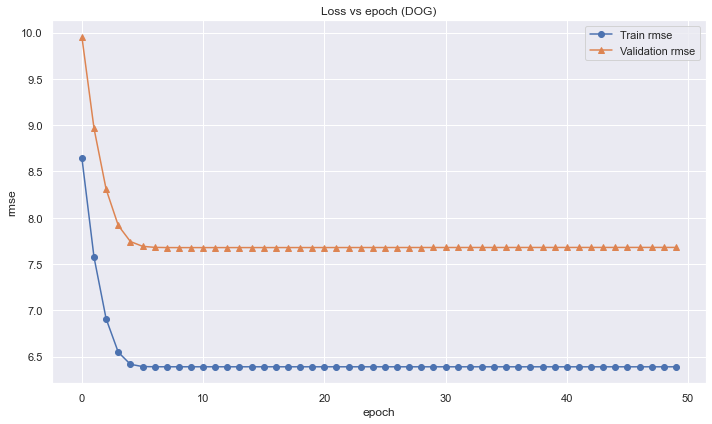

In [76]:
# Support graph
fig,ax = plt.subplots(figsize=(10,6))

ax.set_title('Loss vs epoch (DOG)')
ax.set_xlabel('epoch')
ax.set_ylabel('rmse')
ax.plot(range(len([i**0.5 for i in train_mse_hist])),[i**0.5 for i in train_mse_hist],marker='o',label="Train rmse")
ax.plot(range(len([i**0.5 for i in val_mse_hist])),[i**0.5 for i in val_mse_hist],marker='^',label="Validation rmse")
ax.legend()
fig.tight_layout()
plt.show()


#### Cat Duration Day prediction

Does not remove outlier data

In [77]:
lr_model_df_cat = clean_data(df = cat_df,outlier_removed=False)
X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled = lr_model_df_cat

Dropped columns:
['Animal ID', 'Breed', 'Color', 'DurationDays', 'Intake_DateTime', 'Intake_Season']
The shape of X: (68917, 74)
The shape of y: (68917,)
Train: (46191, 74) 46191 Percentage: 0.67
Val: (9797, 74) 9797 Percentage: 0.14
Test: (12929, 74) 12929 Percentage: 0.19

Predict mean: 39.412487
The shape of X training dataset:(46191, 74), Y training dataset:(46191,)
The shape of X validation dataset:(9797, 74), Y validation dataset:(9797,)
The shape of X testing dataset:(12929, 74), Y testing dataset:(12929,)
-0.0 0.95


In [78]:
# modeling
tuner = kt.RandomSearch(build_model,objective=kt.Objective("val_rmse",direction="min"),max_trials=10)
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_rmse', patience=5,restore_best_weights=False)

tuner.search(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe hyperparameter search is complete. The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
lr_temp_model = tuner.hypermodel.build(best_hps)
temp_history = lr_temp_model.fit(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),verbose=0)

train_mse_hist = temp_history.history['loss']
val_mse_hist = temp_history.history['val_loss']

best_idx = int(np.argmin(val_mse_hist))
best_epoch = best_idx + 1
print('\nBest epoch: %d' % (best_epoch))

# Re-instantiate the hypermodel and train it with the optimal number of epochs from above.
lr_model = tuner.hypermodel.build(best_hps)

# Train 
y_train_pred = lr_model.predict(X_train_scaled)
rmse_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lr_model.predict(X_val_scaled)
rmse_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# prediction 
y_test_pred = lr_model.predict(X_test_scaled)
rmse_test = math.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print("===== Final Model Performance for Cat (days) =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

Reloading Tuner from ./untitled_project/tuner0.json

The hyperparameter search is complete. The optimal learning rate for the optimizer is 0.001.

Best epoch: 20
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step
===== Final Model Performance for Cat (days) =====
Train RMSE: 51.03 | MAE: 23.02
Val   RMSE: 49.08 | MAE: 27.38
Test  RMSE: 47.16 | MAE: 28.71


Outlier data for Cat removed

In [79]:
lr_model_df_cat = clean_data(df = cat_df,outlier_removed=True)
X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled = lr_model_df_cat

Dropped columns:
['Animal ID', 'Breed', 'Color', 'DurationDays', 'Intake_DateTime', 'Intake_Season']
The shape of X: (63723, 74)
The shape of y: (63723,)
Train: (42660, 74) 42660 Percentage: 0.67
Val: (9039, 74) 9039 Percentage: 0.14
Test: (12024, 74) 12024 Percentage: 0.19

Predict mean: 19.161398
The shape of X training dataset:(42660, 74), Y training dataset:(42660,)
The shape of X validation dataset:(9039, 74), Y validation dataset:(9039,)
The shape of X testing dataset:(12024, 74), Y testing dataset:(12024,)
0.0 0.94


In [80]:
# modeling
tuner = kt.RandomSearch(build_model,objective=kt.Objective("val_rmse",direction="min"),max_trials=10)
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_rmse', patience=5,restore_best_weights=False)

tuner.search(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe hyperparameter search is complete. The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
lr_temp_model = tuner.hypermodel.build(best_hps)
temp_history = lr_temp_model.fit(X_train_scaled,y_train,epochs=50,validation_data=(X_val_scaled,y_val),verbose=0)

train_mse_hist = temp_history.history['loss']
val_mse_hist = temp_history.history['val_loss']

best_idx = int(np.argmin(val_mse_hist))
best_epoch = best_idx + 1
print('\nBest epoch: %d' % (best_epoch))

# Re-instantiate the hypermodel and train it with the optimal number of epochs from above.
lr_model = tuner.hypermodel.build(best_hps)

# Train 
y_train_pred = lr_model.predict(X_train_scaled)
rmse_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lr_model.predict(X_val_scaled)
rmse_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# prediction 
y_test_pred = lr_model.predict(X_test_scaled)
rmse_test = math.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print("===== Final Model Performance for Cat (days) =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

Reloading Tuner from ./untitled_project/tuner0.json

The hyperparameter search is complete. The optimal learning rate for the optimizer is 0.001.

Best epoch: 48
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 233us/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 215us/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
===== Final Model Performance for Cat (days) =====
Train RMSE: 23.30 | MAE: 14.52
Val   RMSE: 25.21 | MAE: 16.78
Test  RMSE: 25.53 | MAE: 17.06


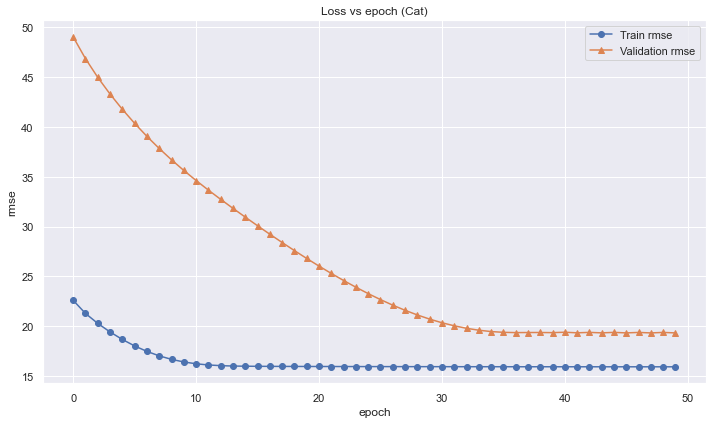

In [81]:
# Support graph
fig,ax = plt.subplots(figsize=(10,6))
ax.set_title('Loss vs epoch (Cat)')
ax.set_xlabel('epoch')
ax.set_ylabel('rmse')
ax.plot(range(len([i**0.5 for i in train_mse_hist])),[i**0.5 for i in train_mse_hist],marker='o',label="Train rmse")
ax.plot(range(len([i**0.5 for i in val_mse_hist])),[i**0.5 for i in val_mse_hist],marker='^',label="Validation rmse")
ax.legend()
fig.tight_layout()
plt.show()


### Model Two: Tree Model (LightGBM)

#### Dog Duration Days prediction

In [82]:
tree_model_df_dog = clean_data(df = dog_df)
X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled = tree_model_df_dog

Dropped columns:
['Animal ID', 'Breed', 'Color', 'DurationDays', 'Intake_DateTime', 'Intake_Season']
The shape of X: (76926, 140)
The shape of y: (76926,)
Train: (58770, 140) 58770 Percentage: 0.76
Val: (9951, 140) 9951 Percentage: 0.13
Test: (8205, 140) 8205 Percentage: 0.11

Predict mean: 7.9844356
The shape of X training dataset:(58770, 140), Y training dataset:(58770,)
The shape of X validation dataset:(9951, 140), Y validation dataset:(9951,)
The shape of X testing dataset:(8205, 140), Y testing dataset:(8205,)
-0.0 0.97


In [ ]:
# Trail
lgb_model_plain = LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=63,
    subsample=0.8,
    max_depth = 10,
    colsample_bytree=0.8,
    min_child_samples = 20,
    random_state=0,
    verbose=-1 
)

lgb_model_plain.fit(X_train, y_train,eval_set=[(X_val, y_val)],eval_metric='rmse',callbacks=[])

# Train
y_train_pred = lgb_model_plain.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lgb_model_plain.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# prediction

y_test_pred = lgb_model_plain.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

# Evaluation
print("===== Final Model Performance for Dog (days) =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

===== Final Model Performance for Dog (days) =====
Train RMSE: 5.89 | MAE: 4.08
Val   RMSE: 7.39 | MAE: 5.30
Test  RMSE: 8.64 | MAE: 6.26


LightGBM Hyperparameter Tunning

In [ ]:
# booster parameters
param_grid = {
    "n_estimators":      [500, 1000, 1500],
    "learning_rate":     [0.05, 0.03, 0.01],
    "num_leaves":        [31, 63, 127],
    "subsample":         [0.7, 0.8, 0.9],
    "max_depth":         [-1, 6, 8, 10],
    "colsample_bytree":  [0.7, 0.8, 0.9],
    "min_child_samples": [20, 50, 100],
}

keys = list(param_grid.keys())
values = list(param_grid.values())
params_combo = list(product(*values))

# random draw
N_TRIALS = 50  
random.seed(0)

best_rmse = float("inf")
best_params = None
lgb_model = None

for i, combo in enumerate(param_grid, 1):
    combo = params_combo[i]

    params = dict(zip(keys,combo))
    params.update({
        "objective":"regression",
        "random_state": 0,
        "verbose": -1,
    })

    model = LGBMRegressor(**params)

    model.fit(X_train, y_train,eval_set=[(X_val, y_val)],eval_metric="rmse",callbacks=[],)

    y_val_pred = model.predict(X_val)
    rmse_val = math.sqrt(mean_squared_error(y_val, y_val_pred))

    print(f"[Trial {i}/{N_TRIALS}] RMSE={rmse_val:.4f}, params={params}")

    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = params
        lgb_model = model

print("\n===== Best params found =====")
print(best_params)

# Train
y_train_pred = lgb_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lgb_model.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# Prediction
y_test_pred = lgb_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

# Evaluation
print("===== Final Model Performance for Dog (days) =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

[Trial 1/50] RMSE=7.3672, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.7, 'min_child_samples': 50, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 2/50] RMSE=7.3622, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.7, 'min_child_samples': 100, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 3/50] RMSE=7.3774, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 4/50] RMSE=7.3736, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.8, 'min_child_samples': 50, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 5/50] RMSE=7.3793, param

In [ ]:
# feature importmence
feature_names = X_train.columns

importances = lgb_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

TOP_N = 20 
fi_df.head(TOP_N)
top_fi = fi_df.head(TOP_N).iloc[::-1] 

plt.figure(figsize=(8, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Feature Importance")
plt.title("LightGBM Feature Importance (Dogs)")
plt.tight_layout()
plt.show()

,feature,importance
1,age_in_days_intake,11216
2,Intake_Month,7650
35,Intake_Year,7374
3,Intake_DayOfWeek,6984
4,Intake_Season_Code,2001
7,Color_White,1651
5,has_name,1640
37,Intake_Type_Owner Surrender,1526
0,Breed_Is_Mix,1483
24,Pattern_Tabby,1477


#### Cat Duration Days prediction

In [93]:
tree_model_df_cat = clean_data(df = cat_df)
X_train,X_val,X_test, y_train,y_val,y_test, X_train_scaled,X_val_scaled,X_test_scaled = tree_model_df_cat

Dropped columns:
['Animal ID', 'Breed', 'Color', 'DurationDays', 'Intake_DateTime', 'Intake_Season']
The shape of X: (63723, 74)
The shape of y: (63723,)
Train: (42660, 74) 42660 Percentage: 0.67
Val: (9039, 74) 9039 Percentage: 0.14
Test: (12024, 74) 12024 Percentage: 0.19

Predict mean: 19.161398
The shape of X training dataset:(42660, 74), Y training dataset:(42660,)
The shape of X validation dataset:(9039, 74), Y validation dataset:(9039,)
The shape of X testing dataset:(12024, 74), Y testing dataset:(12024,)
0.0 0.94


In [ ]:
# trial
lgb_model_plain = LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    verbose=-1 
)

lgb_model_plain.fit(X_train, y_train,eval_set=[(X_val, y_val)],eval_metric='rmse',callbacks=[])

# Train
y_train_pred = lgb_model_plain.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lgb_model_plain.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# Test
y_test_pred = lgb_model_plain.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)


print("===== Final Model Performance for Cat (days) =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

===== Final Model Performance for Cat (days) =====
Train RMSE: 13.28 | MAE: 8.98
Val   RMSE: 18.91 | MAE: 14.98
Test  RMSE: 17.37 | MAE: 12.96


LightGBM Hyperparameter Tunning

In [ ]:
# booster parameters
param_grid = {
    "n_estimators":      [500, 1000, 1500],
    "learning_rate":     [0.05, 0.03, 0.01],
    "num_leaves":        [31, 63, 127],
    "subsample":         [0.7, 0.8, 0.9],
    "max_depth":         [-1, 6, 8, 10],
    "colsample_bytree":  [0.7, 0.8, 0.9],
    "min_child_samples": [20, 50, 100],
}

keys = list(param_grid.keys())
values = list(param_grid.values())
params_combo = list(product(*values))

# random draw
N_TRIALS = 50  
random.seed(0)

best_rmse = float("inf")
best_params = None
lgb_model = None

for i, combo in enumerate(param_grid, 1):
    combo = params_combo[i]

    params = dict(zip(keys,combo))
    params.update({
        "objective":"regression",
        "random_state": 0,
        "verbose": -1,
    })

    model = LGBMRegressor(**params)

    model.fit(X_train, y_train,eval_set=[(X_val, y_val)],eval_metric="rmse",callbacks=[],)

    y_val_pred = model.predict(X_val)
    rmse_val = math.sqrt(mean_squared_error(y_val, y_val_pred))

    print(f"[Trial {i}/{N_TRIALS}] RMSE={rmse_val:.4f}, params={params}")

    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = params
        lgb_model = model

print("\n===== Best params found =====")
print(best_params)
# Train
y_train_pred = lgb_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Validation 
y_val_pred = lgb_model.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)

# prediction
y_test_pred = lgb_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

# Evaluation
print("===== Final Model Performance for Cats (days) =====")
print(f"Train RMSE: {rmse_train:.2f} | MAE: {mae_train:.2f}")
print(f"Val   RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f}")
print(f"Test  RMSE: {rmse_test:.2f} | MAE: {mae_test:.2f}")

[Trial 1/50] RMSE=18.8309, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.7, 'min_child_samples': 50, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 2/50] RMSE=18.7338, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.7, 'min_child_samples': 100, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 3/50] RMSE=18.9412, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 4/50] RMSE=19.0085, params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.7, 'max_depth': -1, 'colsample_bytree': 0.8, 'min_child_samples': 50, 'objective': 'regression', 'random_state': 0, 'verbose': -1}
[Trial 5/50] RMSE=18.8243, 

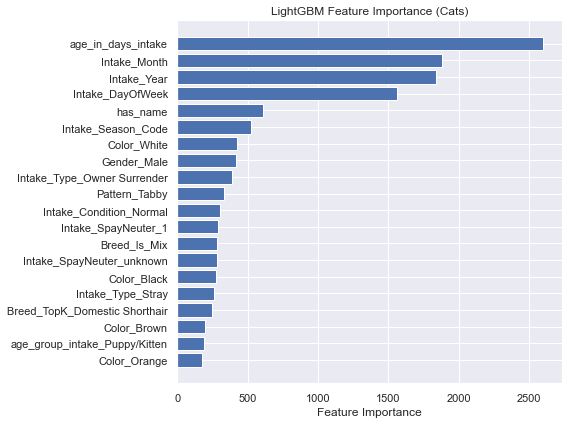

In [96]:
# feature importmence
feature_names = X_train.columns

importances = lgb_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

TOP_N = 20 
fi_df.head(TOP_N)
top_fi = fi_df.head(TOP_N).iloc[::-1] 

plt.figure(figsize=(8, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Feature Importance")
plt.title("LightGBM Feature Importance (Cats)")
plt.tight_layout()
plt.show()